In [1]:
import vector, time, os
import awkward as ak
from coffea import processor
from coffea.nanoevents.methods import candidate
import uproot
from coffea.nanoevents import NanoEventsFactory, BaseSchema, NanoAODSchema
import json
import hist
import numpy as np
import os, glob
import matplotlib.pyplot as plt
import mplhep as hep
plt.style.use([hep.style.ROOT, hep.style.firamath])
import pickle, glob
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
from hist import hist

mkdir -p failed for path /uscms_data/d1/bbbam/.cache/matplotlib: [Errno 30] Read-only file system: '/uscms_data'
Matplotlib created a temporary cache directory at /tmp/matplotlib-qwawcgbh because there was an issue with the default path (/uscms_data/d1/bbbam/.cache/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


### Counts total events 
### Counts events with exactly reco taus and more than 1 reco taus (2 or more)
### Counts events with exactly reco taus and more than 2 reco taus (2 or more) passing trigger
### Plots histogram for invarient mass spectrun from two reco taus (taking two leading pt taus if more than 2) with and without applying trigger determined by flag `trigg_applied_invariant_mass`

In [2]:
import numpy as np
import awkward as ak
import hist
import vector
from coffea import processor


class TauTauJetJetMassProcessor(processor.ProcessorABC):

    def __init__(
        self,
        max_events=2000,
        min_dr_tau=0.5,
        dr_tau_jet=0.4,
        h_mass_bins=np.arange(20, 150, 5),
    ):
        self.max_events = max_events
        self.min_dr_tau = min_dr_tau
        self.dr_tau_jet = dr_tau_jet
        self._processed = 0

        self._accumulator = {
            "h_mass_2jet": hist.Hist.new.Reg(
                len(h_mass_bins) - 1,
                h_mass_bins[0],
                h_mass_bins[-1],
                name="m",
                label="Invariant mass of selected jet pair [GeV]",
            ).Double(),
            "n_events": 0,
        }

    @property
    def accumulator(self):
        return self._accumulator

    def process(self, events):
        if self._processed >= self.max_events:
            return self.accumulator

        remaining = self.max_events - self._processed
        events = events[:remaining]
        self._processed += len(events)
        self._accumulator["n_events"] += len(events)

        reco_tau = events.Tau
        reco_jet = events.Jet

        if len(reco_tau) == 0 or len(reco_jet) == 0:
            return self.accumulator

        # -------------------------------------------------
        # Form tau–tau pairs with ΔR > min_dr_tau
        # -------------------------------------------------
        tau_pairs = ak.combinations(reco_tau, 2)
        tau1 = tau_pairs["0"]
        tau2 = tau_pairs["1"]

        dphi = np.abs(tau1.phi - tau2.phi)
        dphi = ak.where(dphi > np.pi, 2 * np.pi - dphi, dphi)
        deta = tau1.eta - tau2.eta
        dr_tau = np.sqrt(deta**2 + dphi**2)

        tau1 = tau1[dr_tau > self.min_dr_tau]
        tau2 = tau2[dr_tau > self.min_dr_tau]

        if ak.all(ak.num(tau1) == 0):
            return self.accumulator

        # -------------------------------------------------
        # Match selected taus to jets and build jet pairs
        # -------------------------------------------------
        final_jet_pairs = []

        for i_evt in range(len(events)):
            jets_evt = reco_jet[i_evt]
            if len(jets_evt) == 0:
                continue

            jet_pairs_evt = []

            for t1, t2 in zip(tau1[i_evt], tau2[i_evt]):
                matched_jets = []

                for tau in (t1, t2):
                    dphi = np.abs(jets_evt.phi - tau.phi)
                    dphi = np.where(dphi > np.pi, 2 * np.pi - dphi, dphi)
                    deta = jets_evt.eta - tau.eta
                    dr = np.sqrt(deta**2 + dphi**2)

                    idx = np.argmin(dr)
                    if dr[idx] < self.dr_tau_jet:
                        matched_jets.append(jets_evt[idx])

                if len(matched_jets) == 2:
                    jet_pairs_evt.append(matched_jets)

            if len(jet_pairs_evt) == 0:
                continue

            # -------------------------------------------------
            # Select jet pair with leading-jet pT
            # -------------------------------------------------
            lead_pts = [max(jp[0].pt, jp[1].pt) for jp in jet_pairs_evt]
            best_idx = np.argmax(lead_pts)
            final_jet_pairs.append(jet_pairs_evt[best_idx])

        # -------------------------------------------------
        # Invariant mass calculation
        # -------------------------------------------------
        for jets in final_jet_pairs:
            v1 = vector.obj(
                pt=float(jets[0].pt),
                eta=float(jets[0].eta),
                phi=float(jets[0].phi),
                mass=float(jets[0].mass),
            )
            v2 = vector.obj(
                pt=float(jets[1].pt),
                eta=float(jets[1].eta),
                phi=float(jets[1].phi),
                mass=float(jets[1].mass),
            )

            self._accumulator["h_mass_2jet"].fill(m=(v1 + v2).mass)

        return self._accumulator

    def postprocess(self, acc):
        return acc


### The script in below can be used for large scale input files. For now keep these commented

In [21]:
class TriggerCounter(processor.ProcessorABC):

    def __init__(
        self,
        max_events=10000,
        h_mass_bins=np.arange(20, 150, 5),
    ):
        self.max_events = max_events
        self._processed = 0

        # ============================================================
        # Accumulator
        # ============================================================
        self._accumulator = {

            # -----------------------------
            # Visible di-tau mass histogram
            # -----------------------------
            "h_mass": hist.Hist.new.Reg(
                len(h_mass_bins) - 1,
                h_mass_bins[0],
                h_mass_bins[-1],
                name="m",
                label="Visible di-τ mass [GeV]",
            ).Double(),

            # -----------------------------
            # Event counters
            # -----------------------------
            "n_events": 0,
            "n_trig": 0,
        }

    @property
    def accumulator(self):
        return self._accumulator

    # ============================================================
    # PROCESS
    # ============================================================
    def process(self, events):

        # ---------------------------------
        # Limit total processed events
        # ---------------------------------
        if self._processed >= self.max_events:
            return self.accumulator

        remaining = self.max_events - self._processed
        events = events[:remaining]
        self._processed += len(events)

        # Count total events
        self._accumulator["n_events"] += len(events)

        # ============================================================
        # TRIGGER: OR of all DoubleMediumDeepTau paths
        # ============================================================
        hlt = events.HLT

        trigger_names = [
            name for name in hlt.fields
            if "DoubleMediumDeepTau" in name
        ]

        if len(trigger_names) == 0:
            trig_mask = ak.zeros_like(events.event, dtype=bool)
        else:
            trig_mask = ak.any(
                [hlt[name] for name in trigger_names],
                axis=0
            )

        # Count triggered events
        self._accumulator["n_trig"] += int(ak.sum(trig_mask))

        # ============================================================
        # RECO TAUS (triggered events only)
        # ============================================================
        reco_tau = events.Tau
        tau = reco_tau[trig_mask]

        # Require at least 2 taus per event
        mask_atleast2 = ak.num(tau) >= 2
        tau = tau[mask_atleast2]

        # If nothing survives, exit early
        if len(tau) == 0:
            return self.accumulator

        # ============================================================
        # Pick two leading-pT taus per event
        # ============================================================
        order = ak.argsort(tau.pt, axis=1, ascending=False)
        tau_top2 = tau[order][:, :2]

        tau1 = tau_top2[:, 0]
        tau2 = tau_top2[:, 1]

        # ============================================================
        # Build Lorentz vectors
        # ============================================================
        vec1 = vector.array({
            "pt": tau1.pt,
            "eta": tau1.eta,
            "phi": tau1.phi,
            "mass": tau1.mass,
        })

        vec2 = vector.array({
            "pt": tau2.pt,
            "eta": tau2.eta,
            "phi": tau2.phi,
            "mass": tau2.mass,
        })

        # Visible di-tau mass
        h_mass = (vec1 + vec2).mass

        # ============================================================
        # Fill histogram (robust flattening)
        # ============================================================
        self._accumulator["h_mass"].fill(
            m=ak.flatten(h_mass, axis=None)
        )

        return self.accumulator

    # ============================================================
    # POSTPROCESS
    # ============================================================
    def postprocess(self, acc):
        return acc

### Specifying input and out file files paths. Run the script out put will saved to coressponding pkl files

In [22]:
in_filenames = ["HTo2Tau_hadronic.root", "NanoAOD_HToAATo4Tau_M3p7.root", "NanoAOD_HToAATo4Tau_M6.root", "NanoAOD_HToAATo4Tau_M8.root", "NanoAOD_HToAATo4Tau_M10.root"]
out_filenames = ["HTo2Tau_hadronic.pkl", "NanoAOD_HToAATo4Tau_M3p7.pkl", "NanoAOD_HToAATo4Tau_M6.pkl", "NanoAOD_HToAATo4Tau_M8.pkl", "NanoAOD_HToAATo4Tau_M10.pkl"]
out_filenames_trig = ["HTo2Tau_hadronic_trig.pkl", "NanoAOD_HToAATo4Tau_M3p7_trig.pkl", "NanoAOD_HToAATo4Tau_M6_trig.pkl", "NanoAOD_HToAATo4Tau_M8_trig.pkl", "NanoAOD_HToAATo4Tau_M10_trig.pkl"]
in_dir = "root://cmseos.fnal.gov//store/group/lpcml/bbbam/10K_events_feasibility_test"
# filename_ = "../H_AA_CLuster_jupyter_notebooks/hto2Tau_hadronic.root"
out_dir ="output_pkl"
os.makedirs(out_dir, exist_ok=True)  
for i, filename in enumerate(in_filenames):
    file = uproot.open(f"{in_dir}/{filename}")
    # file = uproot.open(f"{filename_}")
    events = NanoEventsFactory.from_root(
        file,
        treepath='Events',
        entry_start=None,
        # entry_stop=1,
        # metadata={"train_dataset_1": "jet"},
        schemaclass=NanoAODSchema,
    ).events()
    p = TriggerCounter()
    out = p.process(events)
    with open(f'{out_dir}/{out_filenames[i]}', 'wb') as f:
        pickle.dump(out, f)
    print(out)
    break

{'h_mass': Hist(Regular(25, 20, 145, name='m', label='Visible di-τ mass [GeV]'), storage=Double()) # Sum: 607.0 (618.0 with flow), 'n_events': 10000, 'n_trig': 626}


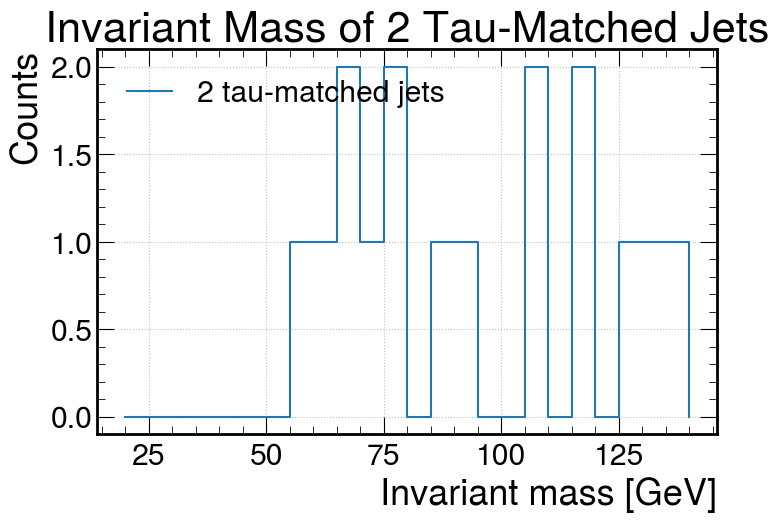

In [15]:
with open(f'{out_dir}/HTo2Tau_hadronic.pkl', 'rb') as f:
    hto2tau = pickle.load(f)
# Access your histogram
h_mass = hto2tau['h_mass_2taujet']

# Get bin edges and values
bin_edges = h_mass.axes[0].edges  # bin edges
values = h_mass.values()          # histogram counts

# Plot
plt.figure(figsize=(8,5))
plt.step(bin_edges[:-1], values, where='post', label='2 tau-matched jets')
plt.xlabel('Invariant mass [GeV]')
plt.ylabel('Counts')
plt.title('Invariant Mass of 2 Tau-Matched Jets')
plt.legend()
plt.grid(True)
plt.show()

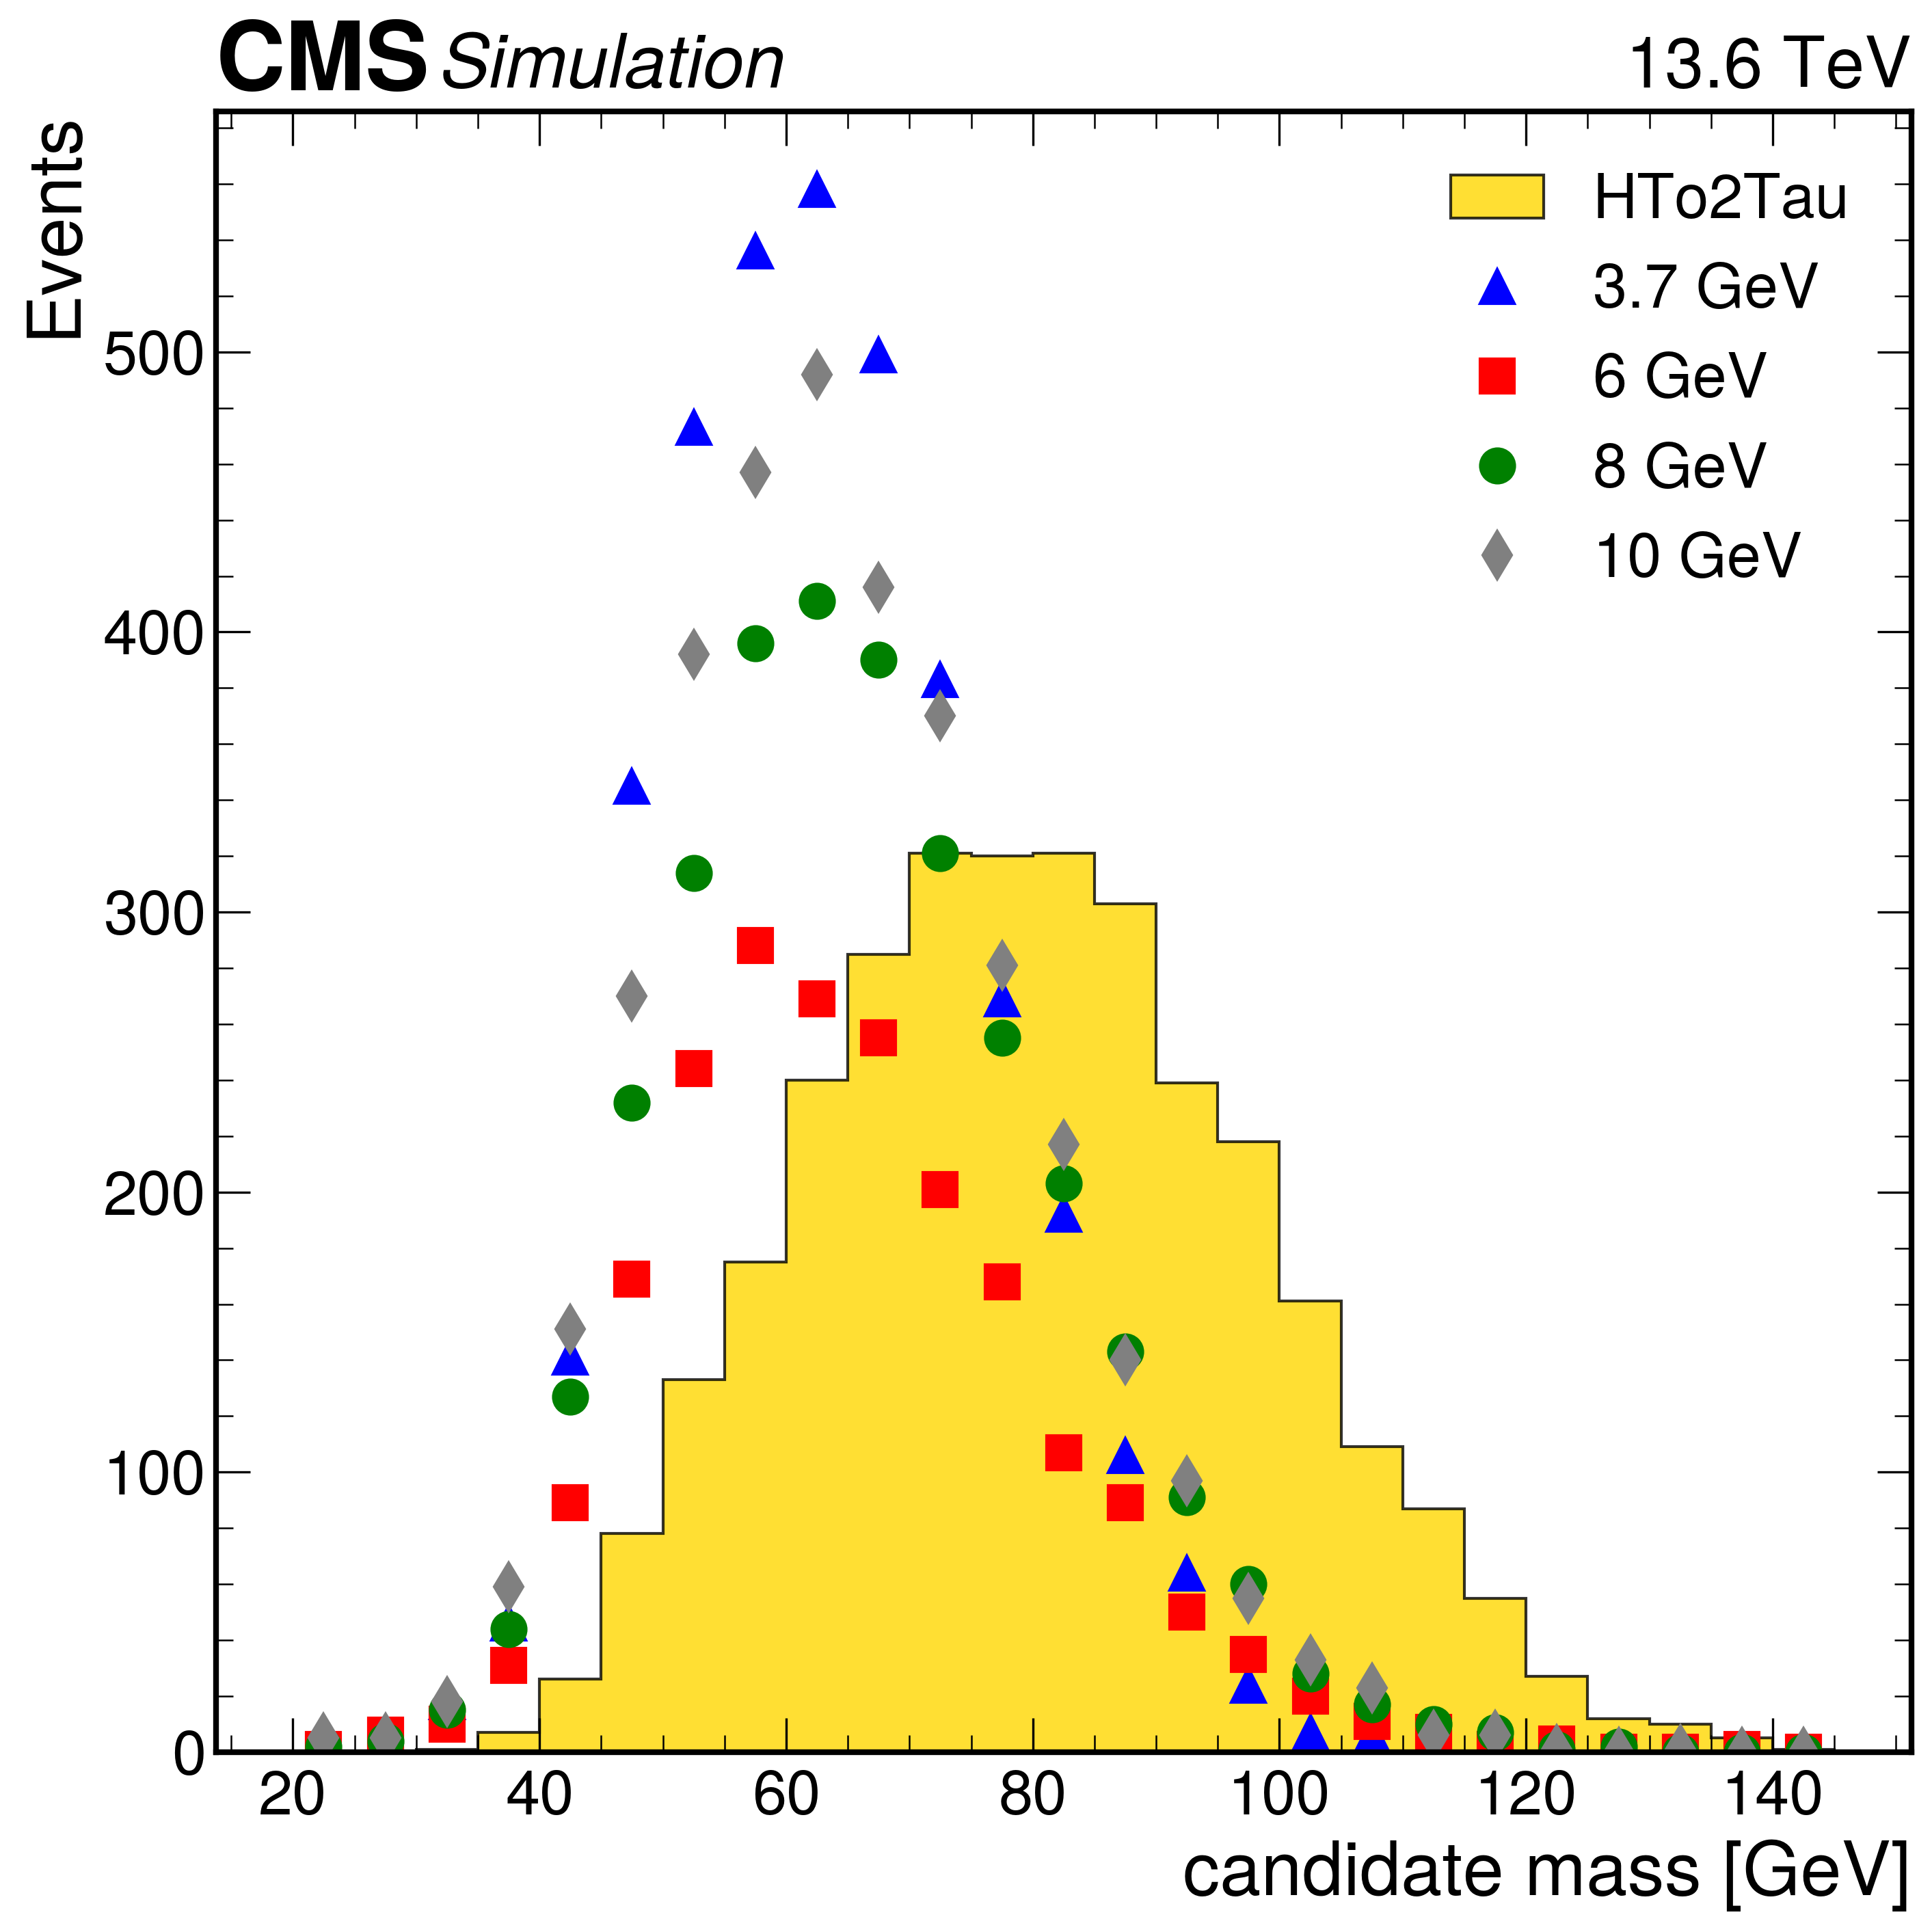

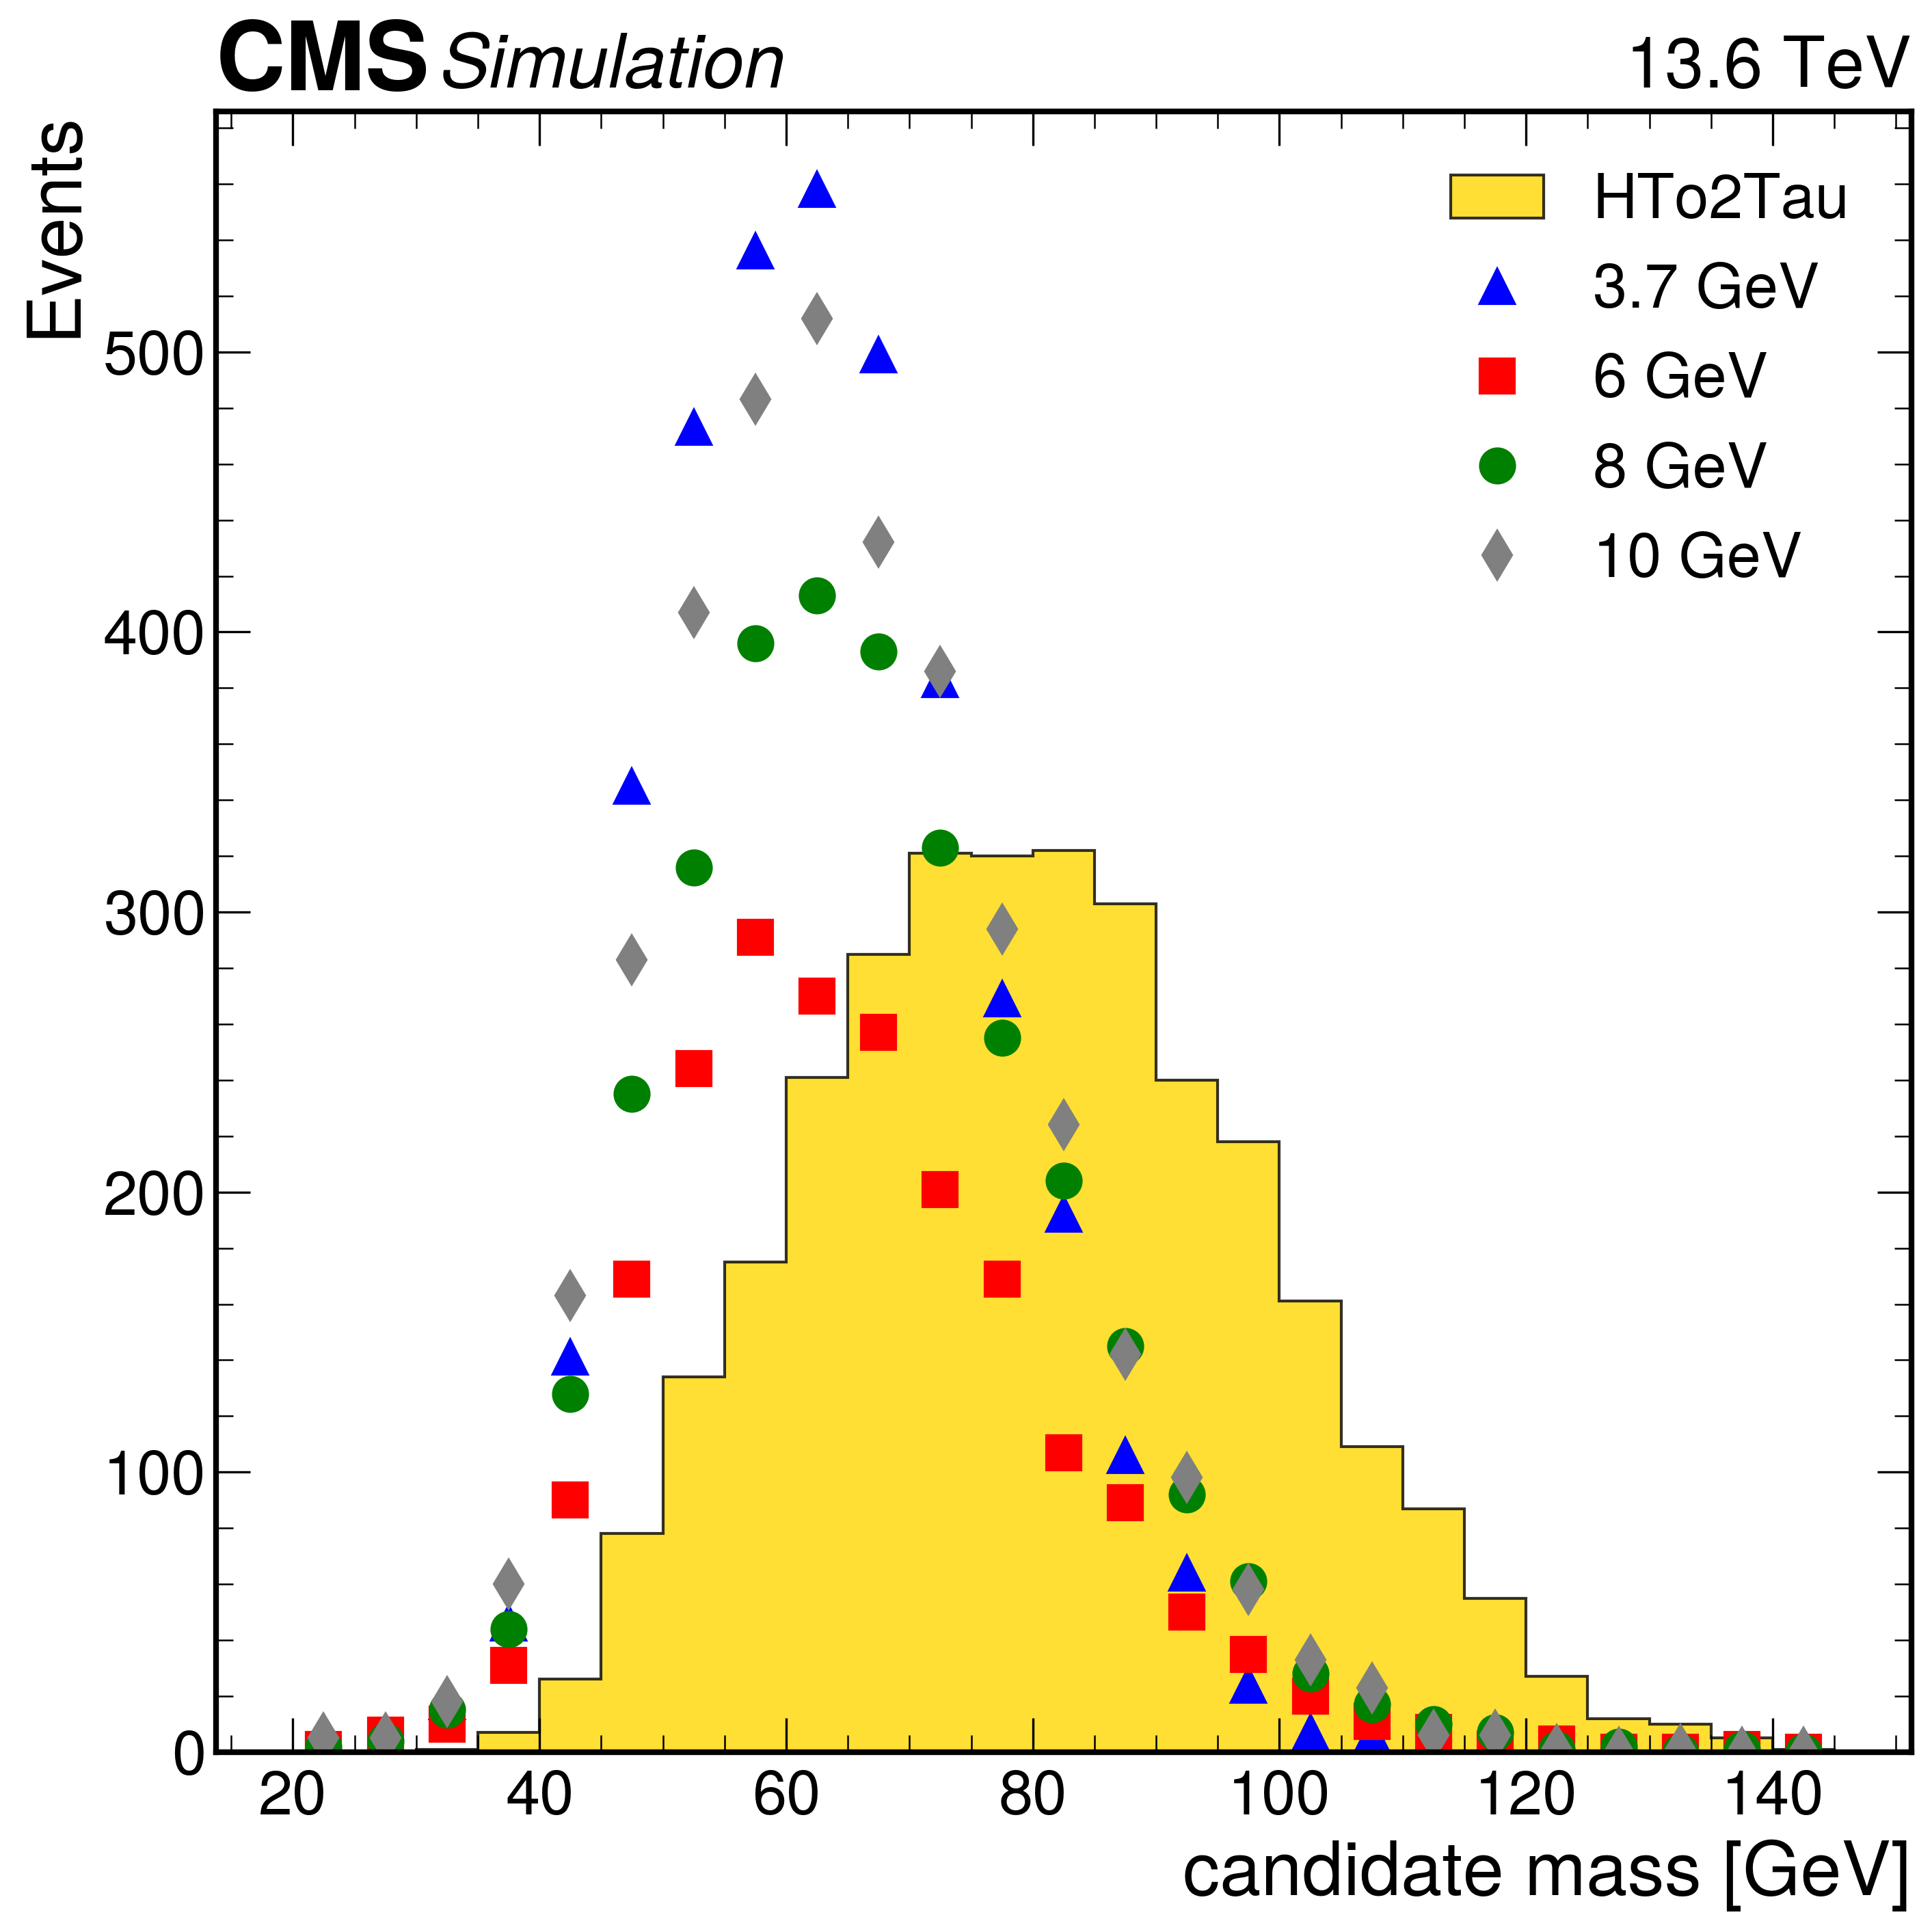

In [10]:
out_dir = '../analysis_run3/TauSVfit/output_pkl'
with open(f'{out_dir}/HTo2Tau_hadronic.pkl', 'rb') as f:
    hto2tau = pickle.load(f)
    
with open(f'{out_dir}/NanoAOD_HToAATo4Tau_M3p7.pkl', 'rb') as f:
    m3p7 = pickle.load(f)
    
with open(f'{out_dir}/NanoAOD_HToAATo4Tau_M6.pkl', 'rb') as f:
    m6 = pickle.load(f)

with open(f'{out_dir}/NanoAOD_HToAATo4Tau_M8.pkl', 'rb') as f:
    m8 = pickle.load(f)
    
with open(f'{out_dir}/NanoAOD_HToAATo4Tau_M10.pkl', 'rb') as f:
    m10 = pickle.load(f)

# Get histograms from accumulator
h_mass_2taus_hto2tau = hto2tau['h_mass_exactly2']
h_mass_more2_hto2tau = hto2tau['h_mass_morethan1']

h_mass_2taus_m3p7 = m3p7['h_mass_exactly2']
h_mass_more2_m3p7 = m3p7['h_mass_morethan1']

h_mass_2taus_m6 = m6['h_mass_exactly2']
h_mass_more2_m6 = m6['h_mass_morethan1']

h_mass_2taus_m8 = m8['h_mass_exactly2']
h_mass_more2_m8 = m8['h_mass_morethan1']

h_mass_2taus_m10 = m10['h_mass_exactly2']
h_mass_more2_m10 = m10['h_mass_morethan1']

# Extract bin edges and counts
bins_hto2tau = h_mass_2taus_hto2tau.axes[0].edges
bin_centers_hto2tau = 0.5 * (bins_hto2tau[1:] + bins_hto2tau[:-1])
counts_2_hto2tau = h_mass_2taus_hto2tau.values()
counts_more2_hto2tau = h_mass_more2_hto2tau.values()

bins_m3p7 = h_mass_2taus_m3p7.axes[0].edges
bin_centers_m3p7 = 0.5 * (bins_m3p7[1:] + bins_m3p7[:-1])
counts_2_m3p7 = h_mass_2taus_m3p7.values()
counts_more2_m3p7 = h_mass_more2_m3p7.values()
errors_2_m3p7 = np.sqrt(counts_2_m3p7)
errors_more2_m3p7 = np.sqrt(counts_more2_m3p7)


bins_m6 = h_mass_2taus_m6.axes[0].edges
bin_centers_m6 = 0.5 * (bins_m6[1:] + bins_m6[:-1])
counts_2_m6 = h_mass_2taus_m6.values()
counts_more2_m6 = h_mass_more2_m6.values()
errors_2_m6 = np.sqrt(counts_2_m6)
errors_more2_m6 = np.sqrt(counts_more2_m6)

bins_m8 = h_mass_2taus_m8.axes[0].edges
bin_centers_m8 = 0.5 * (bins_m8[1:] + bins_m8[:-1])
counts_2_m8 = h_mass_2taus_m8.values()
counts_more2_m8 = h_mass_more2_m8.values()
errors_2_m8 = np.sqrt(counts_2_m8)
errors_more2_m8 = np.sqrt(counts_more2_m8)

bins_m10 = h_mass_2taus_m10.axes[0].edges
bin_centers_m10 = 0.5 * (bins_m10[1:] + bins_m10[:-1])
counts_2_m10 = h_mass_2taus_m10.values()
counts_more2_m10 = h_mass_more2_m10.values()
errors_2_m10 = np.sqrt(counts_2_m10)
errors_more2_m10 = np.sqrt(counts_more2_m10)


# -------------------------
# Plot
# -------------------------

fig, ax = plt.subplots(dpi=300)

# Filled histogram (like yellow Higgs shape)
plt.hist(
    bins_hto2tau[:-1],
    bins=bins_hto2tau,
    weights=counts_2_hto2tau,
    histtype="stepfilled",
    color="gold",
    edgecolor="black",
    alpha=0.8,
    label="HTo2Tau"
)

# Overlay second hist as points with errors
plt.errorbar(
    bin_centers_m3p7,
    counts_2_m3p7,
    # yerr=errors_2_m3p7,
    fmt='^',
    markersize=12,
    color='blue',
    label="3.7 GeV",
    capsize=2
)
plt.errorbar(
    bin_centers_m6,
    counts_2_m6,
    # yerr=errors_2_m6,
    fmt='s',
    markersize=12,
    color='red',
    label="6 GeV",
    capsize=2
)

plt.errorbar(
    bin_centers_m8,
    counts_2_m8,
    # yerr=errors_2_m8,
    fmt='o',
    markersize=12,
    color='green',
    label="8 GeV",
    capsize=2
)

plt.errorbar(
    bin_centers_m10,
    counts_2_m10,
    # yerr=errors_2_m10,
    fmt='d',
    markersize=12,
    color='grey',
    label="10 GeV",
    capsize=5
)

# Labels & styling
plt.xlabel("candidate mass [GeV]")
plt.ylabel("Events")
# plt.title("candidate_mass")
plt.legend()
hep.cms.label(llabel="Simulation", rlabel="13.6 TeV", loc=0, ax=ax)
plt.tight_layout()
# plt.savefig(f'plots/candidate_invarient_mass_from_excatelty_2_reco_tau_pass_trig.pdf',facecolor='w',dpi=300)



fig, ax = plt.subplots(dpi=300)

# Filled histogram (like yellow Higgs shape)
plt.hist(
    bins_hto2tau[:-1],
    bins=bins_hto2tau,
    weights=counts_more2_hto2tau,
    histtype="stepfilled",
    color="gold",
    edgecolor="black",
    alpha=0.8,
    label="HTo2Tau"
)

# Overlay second hist as points with errors
plt.errorbar(
    bin_centers_m3p7,
    counts_more2_m3p7,
    # yerr=errors_more2_m3p7,
    fmt='^',
    markersize=12,
    color='blue',
    label="3.7 GeV",
    capsize=2
)
plt.errorbar(
    bin_centers_m6,
    counts_more2_m6,
    # yerr=errors_more2_m6,
    fmt='s',
    markersize=12,
    color='red',
    label="6 GeV",
    capsize=2
)

plt.errorbar(
    bin_centers_m8,
    counts_more2_m8,
    # yerr=errors_more2_m8,
    fmt='o',
    markersize=12,
    color='green',
    label="8 GeV",
    capsize=2
)

plt.errorbar(
    bin_centers_m10,
    counts_more2_m10,
    # yerr=errors_2_m10,
    fmt='d',
    markersize=12,
    color='grey',
    label="10 GeV",
    capsize=5
)

# Labels & styling
plt.xlabel("candidate mass [GeV]")
plt.ylabel("Events")
# plt.title("candidate_mass")
plt.legend()
hep.cms.label(llabel="Simulation", rlabel="13.6 TeV", loc=0, ax=ax)
plt.tight_layout()
# plt.savefig(f'plot/candidate_invarient_mass_from_2_or_more_reco_tau_pass_trig.pdf',facecolor='w',dpi=300)


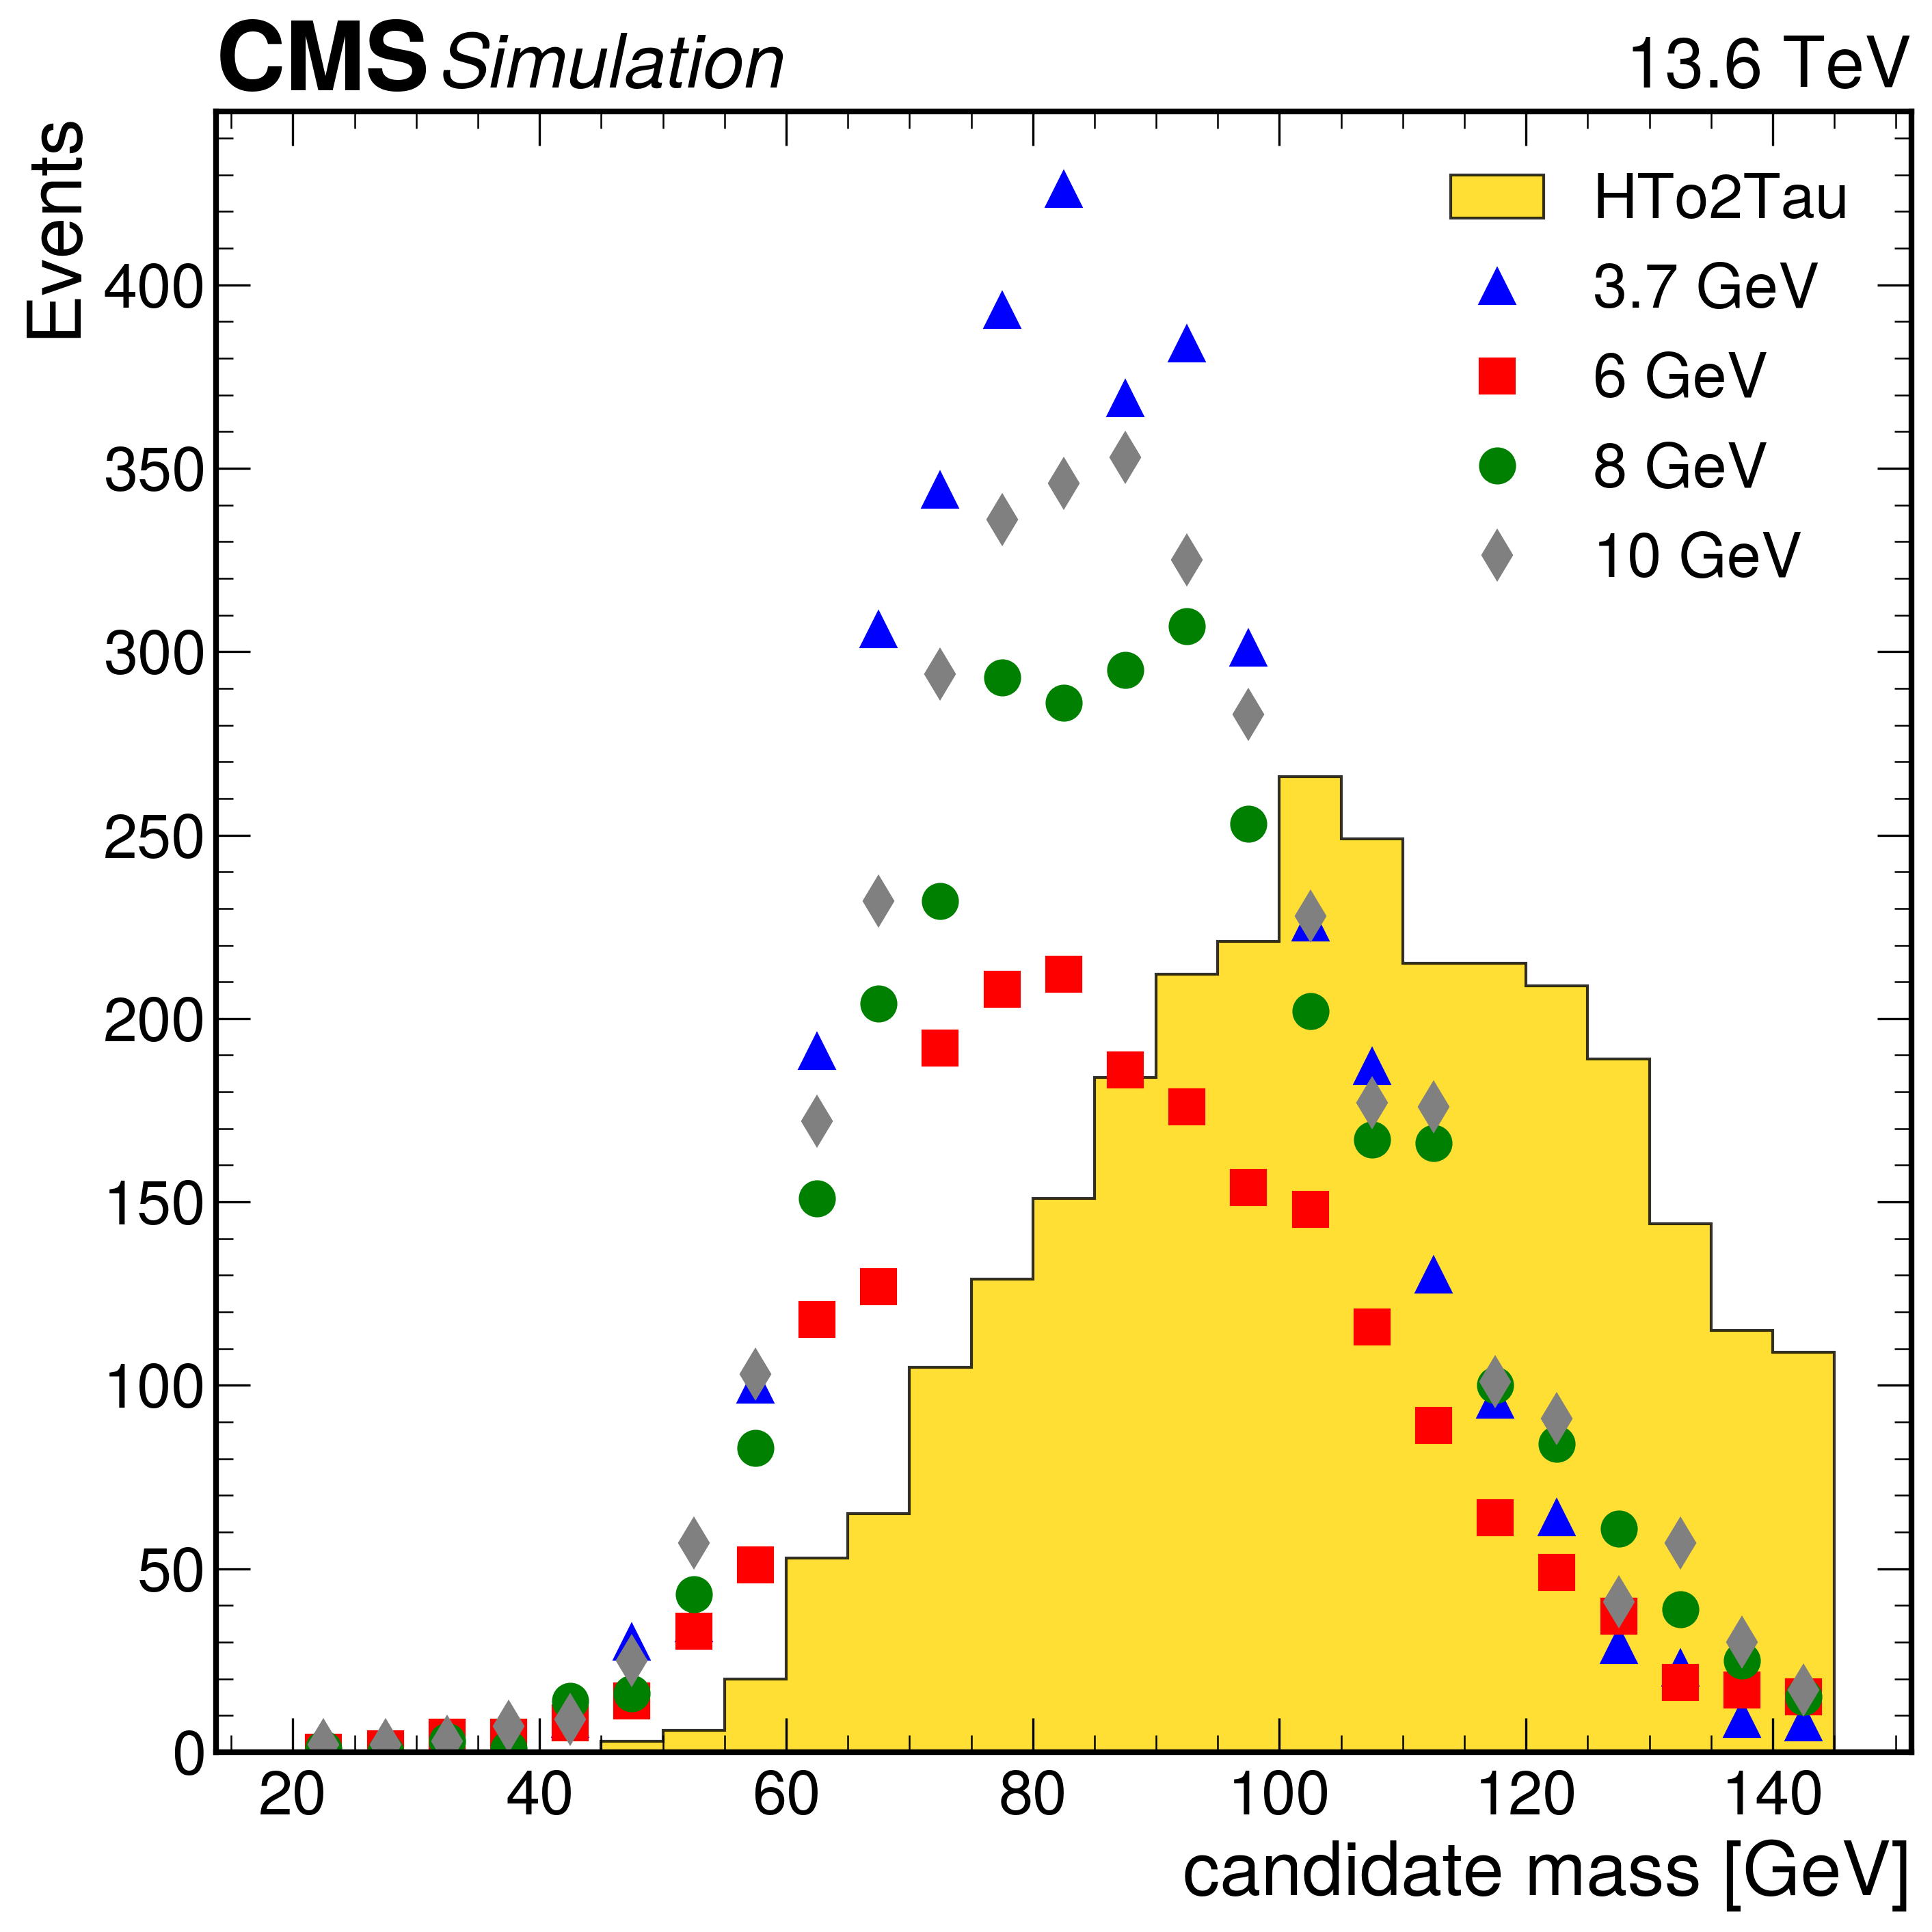

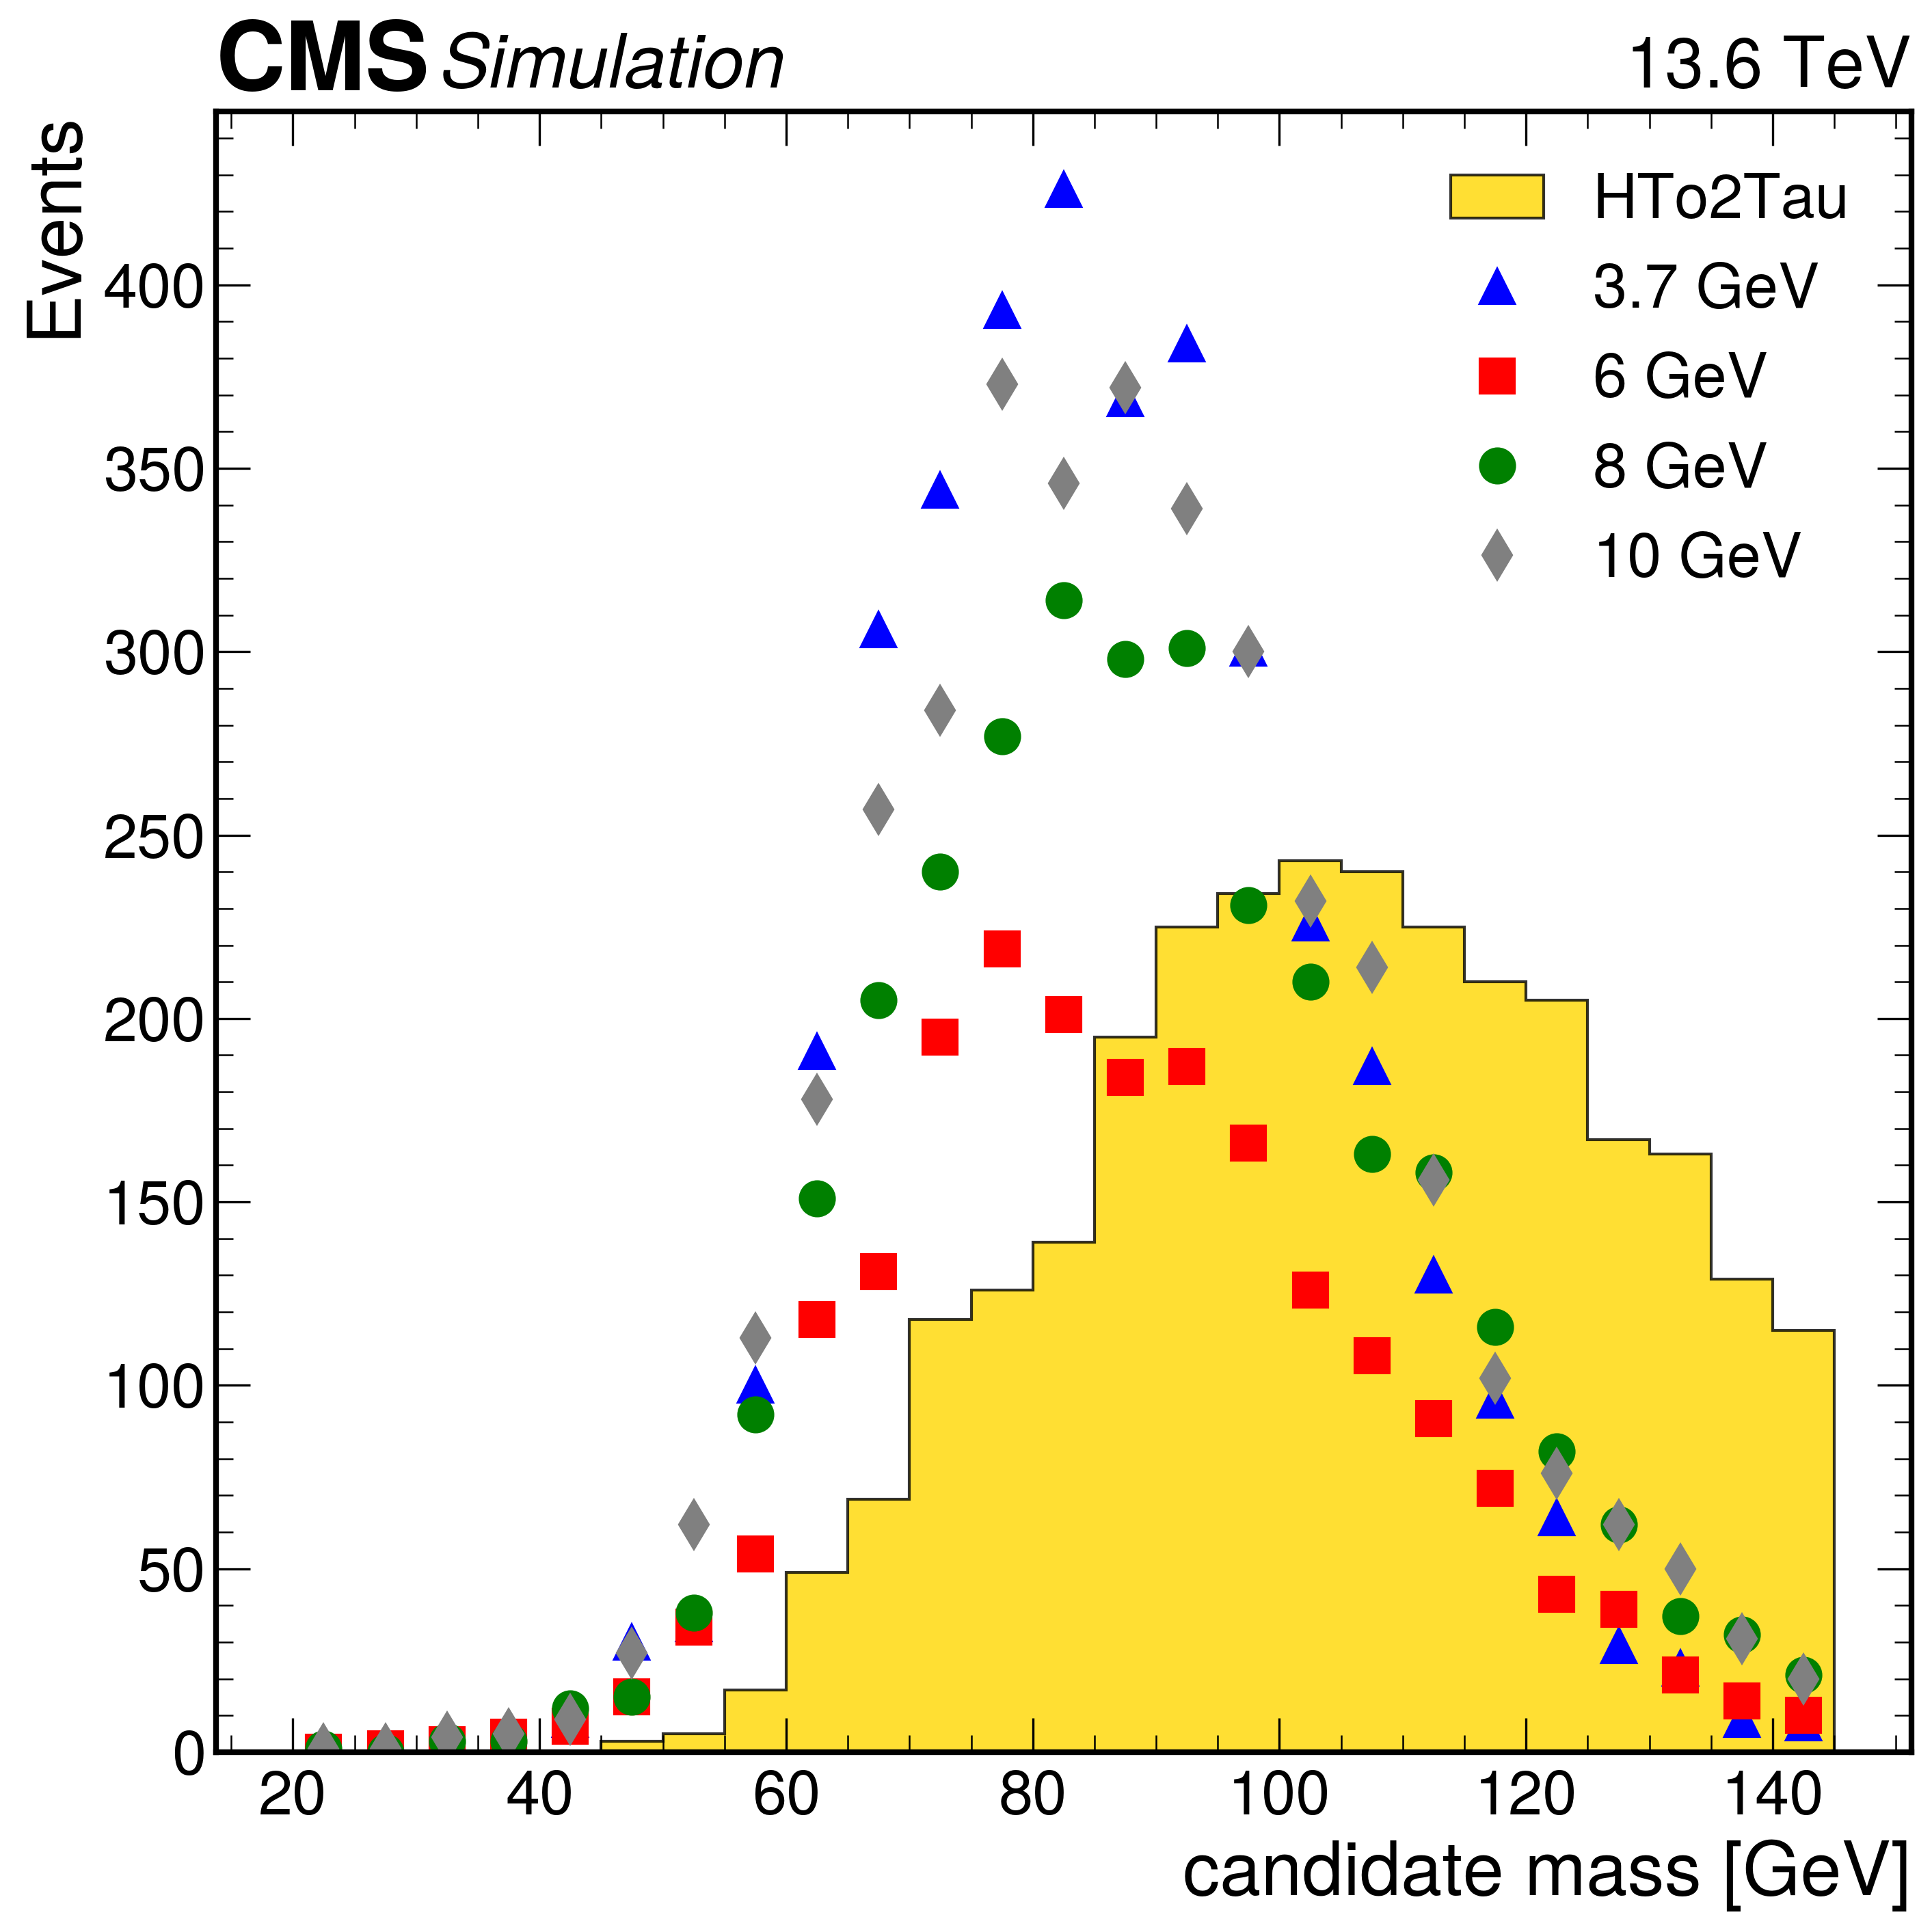

In [14]:
out_dir = '../analysis_run3/TauSVfit/output_pkl'
with open(f'{out_dir}/HTo2Tau_hadronic.pkl', 'rb') as f:
    hto2tau = pickle.load(f)
    
with open(f'{out_dir}/NanoAOD_HToAATo4Tau_M3p7.pkl', 'rb') as f:
    m3p7 = pickle.load(f)
    
with open(f'{out_dir}/NanoAOD_HToAATo4Tau_M6.pkl', 'rb') as f:
    m6 = pickle.load(f)

with open(f'{out_dir}/NanoAOD_HToAATo4Tau_M8.pkl', 'rb') as f:
    m8 = pickle.load(f)
    
with open(f'{out_dir}/NanoAOD_HToAATo4Tau_M10.pkl', 'rb') as f:
    m10 = pickle.load(f)

# Get histograms from accumulator
h_mass_2taus_hto2tau = hto2tau['h_FastMTT_mass_exactly2']
h_mass_more2_hto2tau = hto2tau['h_FastMTT_mass_morethan1']

h_mass_2taus_m3p7 = m3p7['h_FastMTT_mass_exactly2']
h_mass_more2_m3p7 = m3p7['h_FastMTT_mass_morethan1']

h_mass_2taus_m6 = m6['h_FastMTT_mass_exactly2']
h_mass_more2_m6 = m6['h_FastMTT_mass_morethan1']

h_mass_2taus_m8 = m8['h_FastMTT_mass_exactly2']
h_mass_more2_m8 = m8['h_FastMTT_mass_morethan1']

h_mass_2taus_m10 = m10['h_FastMTT_mass_exactly2']
h_mass_more2_m10 = m10['h_FastMTT_mass_morethan1']

# Extract bin edges and counts
bins_hto2tau = h_mass_2taus_hto2tau.axes[0].edges
bin_centers_hto2tau = 0.5 * (bins_hto2tau[1:] + bins_hto2tau[:-1])
counts_2_hto2tau = h_mass_2taus_hto2tau.values()
counts_more2_hto2tau = h_mass_more2_hto2tau.values()

bins_m3p7 = h_mass_2taus_m3p7.axes[0].edges
bin_centers_m3p7 = 0.5 * (bins_m3p7[1:] + bins_m3p7[:-1])
counts_2_m3p7 = h_mass_2taus_m3p7.values()
counts_more2_m3p7 = h_mass_more2_m3p7.values()
errors_2_m3p7 = np.sqrt(counts_2_m3p7)
errors_more2_m3p7 = np.sqrt(counts_more2_m3p7)


bins_m6 = h_mass_2taus_m6.axes[0].edges
bin_centers_m6 = 0.5 * (bins_m6[1:] + bins_m6[:-1])
counts_2_m6 = h_mass_2taus_m6.values()
counts_more2_m6 = h_mass_more2_m6.values()
errors_2_m6 = np.sqrt(counts_2_m6)
errors_more2_m6 = np.sqrt(counts_more2_m6)

bins_m8 = h_mass_2taus_m8.axes[0].edges
bin_centers_m8 = 0.5 * (bins_m8[1:] + bins_m8[:-1])
counts_2_m8 = h_mass_2taus_m8.values()
counts_more2_m8 = h_mass_more2_m8.values()
errors_2_m8 = np.sqrt(counts_2_m8)
errors_more2_m8 = np.sqrt(counts_more2_m8)

bins_m10 = h_mass_2taus_m10.axes[0].edges
bin_centers_m10 = 0.5 * (bins_m10[1:] + bins_m10[:-1])
counts_2_m10 = h_mass_2taus_m10.values()
counts_more2_m10 = h_mass_more2_m10.values()
errors_2_m10 = np.sqrt(counts_2_m10)
errors_more2_m10 = np.sqrt(counts_more2_m10)


# -------------------------
# Plot
# -------------------------

fig, ax = plt.subplots(dpi=300)

# Filled histogram (like yellow Higgs shape)
plt.hist(
    bins_hto2tau[:-1],
    bins=bins_hto2tau,
    weights=counts_2_hto2tau,
    histtype="stepfilled",
    color="gold",
    edgecolor="black",
    alpha=0.8,
    label="HTo2Tau"
)

# Overlay second hist as points with errors
plt.errorbar(
    bin_centers_m3p7,
    counts_2_m3p7,
    # yerr=errors_2_m3p7,
    fmt='^',
    markersize=12,
    color='blue',
    label="3.7 GeV",
    capsize=2
)
plt.errorbar(
    bin_centers_m6,
    counts_2_m6,
    # yerr=errors_2_m6,
    fmt='s',
    markersize=12,
    color='red',
    label="6 GeV",
    capsize=2
)

plt.errorbar(
    bin_centers_m8,
    counts_2_m8,
    # yerr=errors_2_m8,
    fmt='o',
    markersize=12,
    color='green',
    label="8 GeV",
    capsize=2
)

plt.errorbar(
    bin_centers_m10,
    counts_2_m10,
    # yerr=errors_2_m10,
    fmt='d',
    markersize=12,
    color='grey',
    label="10 GeV",
    capsize=5
)

# Labels & styling
plt.xlabel("candidate mass [GeV]")
plt.ylabel("Events")
# plt.title("candidate_mass")
plt.legend()
hep.cms.label(llabel="Simulation", rlabel="13.6 TeV", loc=0, ax=ax)
plt.tight_layout()
# plt.savefig(f'plots/candidate_invarient_FastMTT_mass_from_excatelty_2_reco_tau_pass_trig.pdf',facecolor='w',dpi=300)



fig, ax = plt.subplots(dpi=300)

# Filled histogram (like yellow Higgs shape)
plt.hist(
    bins_hto2tau[:-1],
    bins=bins_hto2tau,
    weights=counts_more2_hto2tau,
    histtype="stepfilled",
    color="gold",
    edgecolor="black",
    alpha=0.8,
    label="HTo2Tau"
)

# Overlay second hist as points with errors
plt.errorbar(
    bin_centers_m3p7,
    counts_more2_m3p7,
    # yerr=errors_more2_m3p7,
    fmt='^',
    markersize=12,
    color='blue',
    label="3.7 GeV",
    capsize=2
)
plt.errorbar(
    bin_centers_m6,
    counts_more2_m6,
    # yerr=errors_more2_m6,
    fmt='s',
    markersize=12,
    color='red',
    label="6 GeV",
    capsize=2
)

plt.errorbar(
    bin_centers_m8,
    counts_more2_m8,
    # yerr=errors_more2_m8,
    fmt='o',
    markersize=12,
    color='green',
    label="8 GeV",
    capsize=2
)

plt.errorbar(
    bin_centers_m10,
    counts_more2_m10,
    # yerr=errors_2_m10,
    fmt='d',
    markersize=12,
    color='grey',
    label="10 GeV",
    capsize=5
)

# Labels & styling
plt.xlabel("candidate mass [GeV]")
plt.ylabel("Events")
# plt.title("candidate_mass")
plt.legend()
hep.cms.label(llabel="Simulation", rlabel="13.6 TeV", loc=0, ax=ax)
plt.tight_layout()
# plt.savefig(f'plot/candidate_invarient_mass_from_2_or_more_reco_tau_pass_trig.pdf',facecolor='w',dpi=300)


In [ ]:
# from pprint import pprint
# for i, out_file in enumerate(out_filenames):
#     print("dataset  ",in_filenames[i]) 
#     with open(f'{out_file}', 'rb') as f:
#         out = pickle.load(f)
#     pprint({k: v for k, v in out.items() if not hasattr(v, "axes")})

### Simply counts Number of events passed the trigger and plot histogram with invarient mass from reco tau (select 2 leading pt tau)

In [12]:

class TriggerCounter(processor.ProcessorABC):

    def __init__(
        self,
        max_events=10000,
        h_mass_bins=np.arange(20, 150, 5),
    ):
        self.max_events = max_events
        self._processed = 0

        # ============================================================
        # Accumulator
        # ============================================================
        self._accumulator = {

            # -----------------------------
            # Visible di-tau mass histogram
            # -----------------------------
            "h_mass": hist.Hist.new.Reg(
                len(h_mass_bins) - 1,
                h_mass_bins[0],
                h_mass_bins[-1],
                name="m",
                label="Visible di-τ mass [GeV]",
            ).Double(),

            # -----------------------------
            # Event counters
            # -----------------------------
            "n_events": 0,
            "n_trig": 0,
        }

    @property
    def accumulator(self):
        return self._accumulator

    # ============================================================
    # PROCESS
    # ============================================================
    def process(self, events):

        # ---------------------------------
        # Limit total processed events
        # ---------------------------------
        if self._processed >= self.max_events:
            return self.accumulator

        remaining = self.max_events - self._processed
        events = events[:remaining]
        self._processed += len(events)

        # Count total events
        self._accumulator["n_events"] += len(events)

        # ============================================================
        # TRIGGER: OR of all DoubleMediumDeepTau paths
        # ============================================================
        hlt = events.HLT

        trigger_names = [
            name for name in hlt.fields
            if "DoubleMediumDeepTau" in name
        ]

        if len(trigger_names) == 0:
            trig_mask = ak.zeros_like(events.event, dtype=bool)
        else:
            trig_mask = ak.any(
                [hlt[name] for name in trigger_names],
                axis=0
            )

        # Count triggered events
        self._accumulator["n_trig"] += int(ak.sum(trig_mask))

        # ============================================================
        # RECO TAUS (triggered events only)
        # ============================================================
        reco_tau = events.Tau
        tau = reco_tau[trig_mask]

        # Require at least 2 taus per event
        mask_atleast2 = ak.num(tau) >= 2
        tau = tau[mask_atleast2]

        # If nothing survives, exit early
        if len(tau) == 0:
            return self.accumulator

        # ============================================================
        # Pick two leading-pT taus per event
        # ============================================================
        order = ak.argsort(tau.pt, axis=1, ascending=False)
        tau_top2 = tau[order][:, :2]

        tau1 = tau_top2[:, 0]
        tau2 = tau_top2[:, 1]

        # ============================================================
        # Build Lorentz vectors
        # ============================================================
        vec1 = vector.array({
            "pt": tau1.pt,
            "eta": tau1.eta,
            "phi": tau1.phi,
            "mass": tau1.mass,
        })

        vec2 = vector.array({
            "pt": tau2.pt,
            "eta": tau2.eta,
            "phi": tau2.phi,
            "mass": tau2.mass,
        })

        # Visible di-tau mass
        h_mass = (vec1 + vec2).mass

        # ============================================================
        # Fill histogram (robust flattening)
        # ============================================================
        self._accumulator["h_mass"].fill(
            m=ak.flatten(h_mass, axis=None)
        )

        return self.accumulator

    # ============================================================
    # POSTPROCESS
    # ============================================================
    def postprocess(self, acc):
        return acc


### Give input and outpu file path. run following line and out put will saved as pkl file

In [5]:
# in_filenames = ["HTo2Tau_hadronic.root", "NanoAOD_HToAATo4Tau_M3p7.root", "NanoAOD_HToAATo4Tau_M6.root", "NanoAOD_HToAATo4Tau_M8.root", "NanoAOD_HToAATo4Tau_M10.root"]
# out_filenames = ["HTo2Tau_hadronic_only_trig.pkl", "NanoAOD_HToAATo4Tau_M3p7_only_trig.pkl", "NanoAOD_HToAATo4Tau_M6_only_trig.pkl", "NanoAOD_HToAATo4Tau_M8_only_trig.pkl", "NanoAOD_HToAATo4Tau_M10_only_trig.pkl"]
# in_dir = "root://cmseos.fnal.gov//store/group/lpcml/bbbam/10K_events_feasibility_test"
# out_dir = "output_pkl"

# for i, filename in enumerate(in_filenames):
#     file = uproot.open(f'{in_dir}/{filename}')
#     events = NanoEventsFactory.from_root(
#         file,
#         treepath='Events',
#         entry_start=None,
#         # entry_stop=1,
#         # metadata={"train_dataset_1": "jet"},
#         schemaclass=NanoAODSchema,
#     ).events()
#     p = TriggerCounter()
#     out = p.process(events)
#     with open(f'{out_dir}/{out_filenames[i]}', 'wb') as f:
#         pickle.dump(out, f)
#     print(out)

NameError: name 'TriggerCounter' is not defined

In [19]:
out_filenames = ["HTo2Tau_hadronic.pkl", "NanoAOD_HToAATo4Tau_M3p7.pkl", "NanoAOD_HToAATo4Tau_M6.pkl", "NanoAOD_HToAATo4Tau_M8.pkl", "NanoAOD_HToAATo4Tau_M10.pkl"]
out_dir = '../analysis_run3/TauSVfit/output_pkl'
for file in out_filenames:    
    with open(f'{out_dir}/{file}', 'rb') as f:
        hto2tau = pickle.load(f)
        n_events = hto2tau['n_events']
        n_exactly2 = hto2tau['n_exactly2']
        n_morethan1 = hto2tau['n_morethan1']
        n_exactly2_trig = hto2tau['n_exactly2_trig']
        n_morethan1_trig = hto2tau['n_morethan1_trig']
        
        print(" n_events",  n_events)
        print("n_exactly2 ",n_exactly2 )
        print(" n_exactly2_trig",  n_exactly2_trig)
        print("n_exactly2 ",n_exactly2 )
        print(" n_morethan1_trig",  n_morethan1_trig)
        print("-------------")
    # print(hto2tau.keys())  
# h_mass_2taus_hto2tau = hto2tau['h_mass_exactly2']
# h_mass_morethan1_taus_hto2tau = hto2tau['h_mass_morethan1']
# h_mass_2taus_hto2tau_cor = hto2tau['h_FastMTT_mass_exactly2']
# h_mass_morethan1_taus_hto2tau_cor = hto2tau['h_FastMTT_mass_morethan1']

# bins_hto2tau = h_mass_2taus_hto2tau.axes[0].edges
# bin_centers_hto2tau = 0.5 * (bins_hto2tau[1:] + bins_hto2tau[:-1])
# counts_2_hto2tau = h_mass_2taus_hto2tau.values()
# counts_more2_hto2tau = h_mass_more2_hto2tau.values()
# counts_2_hto2tau_cor = h_mass_2taus_hto2tau_cor.values()
# counts_more2_hto2tau_cor = h_mass_morethan1_taus_hto2tau_cor.values()
# fig, ax = plt.subplots(dpi=100)

# # Filled histogram (like yellow Higgs shape)
# plt.hist(
#     bins_hto2tau[:-1],
#     bins=bins_hto2tau,
#     weights=counts_2_hto2tau,
#     histtype="step",
#     # color="gold",
#     edgecolor="red",
#     alpha=0.8,
#     label="HTo2Tau"
# )

# plt.hist(
#     bins_hto2tau[:-1],
#     bins=bins_hto2tau,
#     weights=counts_2_hto2tau_cor,
#     histtype="step",
#     # color="gold",
#     edgecolor="green",
#     alpha=0.8,
#     label="HTo2Tau_FastMTT"
# )

# plt.hist(
#     bins_hto2tau[:-1],
#     bins=bins_hto2tau,
#     weights=counts_more2_hto2tau_cor,
#     histtype="step",
#     # color="gold",
#     edgecolor="blue",
#     alpha=0.8,
#     label="HTo2Tau_FastMTT"
# )


# plt.xlabel("candidate mass [GeV]")
# plt.ylabel("Events")
# # plt.title("candidate_mass")
# plt.legend()
# hep.cms.label(llabel="Simulation", rlabel="13.6 TeV", loc=0, ax=ax)
# plt.tight_layout()

 n_events 10000
n_exactly2  5292
 n_exactly2_trig 607
n_exactly2  5292
 n_morethan1_trig 608
-------------
 n_events 10000
n_exactly2  4207
 n_exactly2_trig 105
n_exactly2  4207
 n_morethan1_trig 105
-------------
 n_events 10000
n_exactly2  3415
 n_exactly2_trig 80
n_exactly2  3415
 n_morethan1_trig 81
-------------
 n_events 10000
n_exactly2  5360
 n_exactly2_trig 122
n_exactly2  5360
 n_morethan1_trig 122
-------------
 n_events 10000
n_exactly2  6055
 n_exactly2_trig 155
n_exactly2  6055
 n_morethan1_trig 156
-------------


(array([  0.,   0.,   0.,   0.,   0.,   1.,   5.,  13.,  37.,  53.,  96.,
        123., 146., 174., 216., 247., 260., 235., 219., 223., 213., 204.,
        162., 145.,  94.,  86.,  62.,  42.,  21.]),
 array([ 20.,  25.,  30.,  35.,  40.,  45.,  50.,  55.,  60.,  65.,  70.,
         75.,  80.,  85.,  90.,  95., 100., 105., 110., 115., 120., 125.,
        130., 135., 140., 145., 150., 155., 160., 165.]),
 [<matplotlib.patches.Polygon at 0x7f79d6ec5a90>])

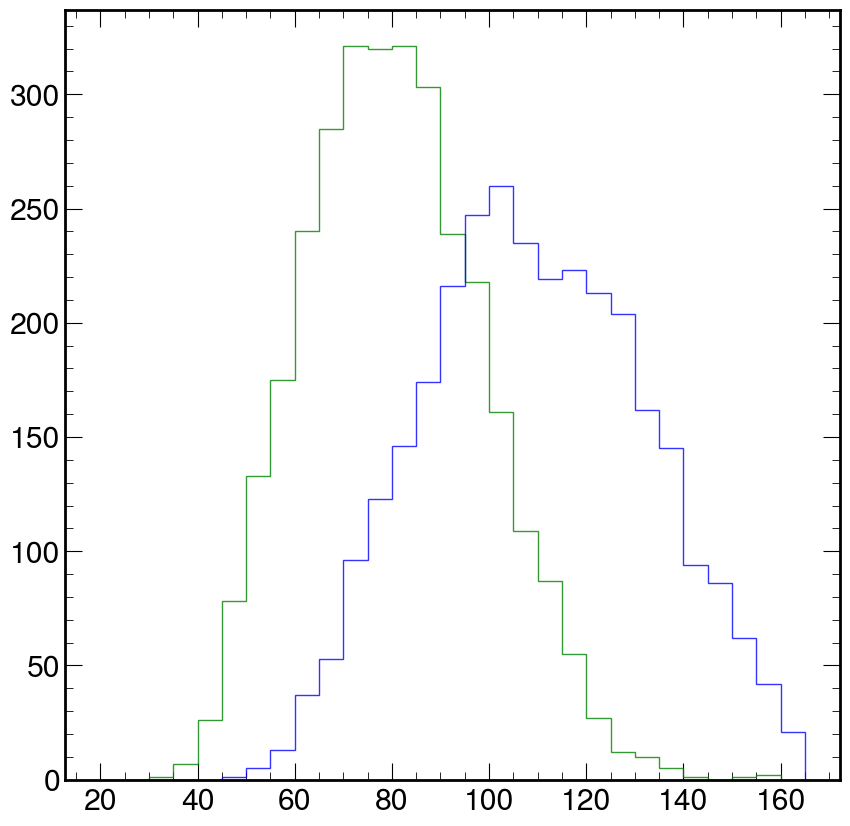

In [9]:

out_dir = '../analysis_run3/TauSVfit/tau_fastmtt_output.pkl'
with open(f'{out_dir}', 'rb') as f:
        out = pickle.load(f)


# Extract histograms
h1 = out["h_mass_exactly2"]
h2 = out["h_fastmtt_mass_exactly2"]

bins = h1["bins"]
vals1 = h1["values"]
vals2 = h2["values"]

# # Bin centers (optional)
# bin_centers = 0.5 * (bins[:-1] + bins[1:])

# plt.figure(figsize=(6,6))

# plt.step(bins[:-1], vals1, where="post", label="Exact 2 taus (SVfit)")
# plt.step(bins[:-1], vals2, where="post", label="Exact 2 taus (FastMTT)")

# plt.xlabel("Mass [GeV]")
# plt.ylabel("Events")
# # plt.title("Invariant Mass Distribution")
# plt.legend()
# # plt.grid(True)

# plt.tight_layout()
# plt.show()




plt.hist(
    bins[:-1],
    bins=bins,
    weights=vals1,
    histtype="step",
    # color="gold",
    edgecolor="green",
    alpha=0.8,
    label="HTo2Tau"
)

plt.hist(
    bins[:-1],
    bins=bins,
    weights=vals2,
    histtype="step",
    # color="gold",
    edgecolor="blue",
    alpha=0.8,
    label="HTo2Tau_FastMTT"
)

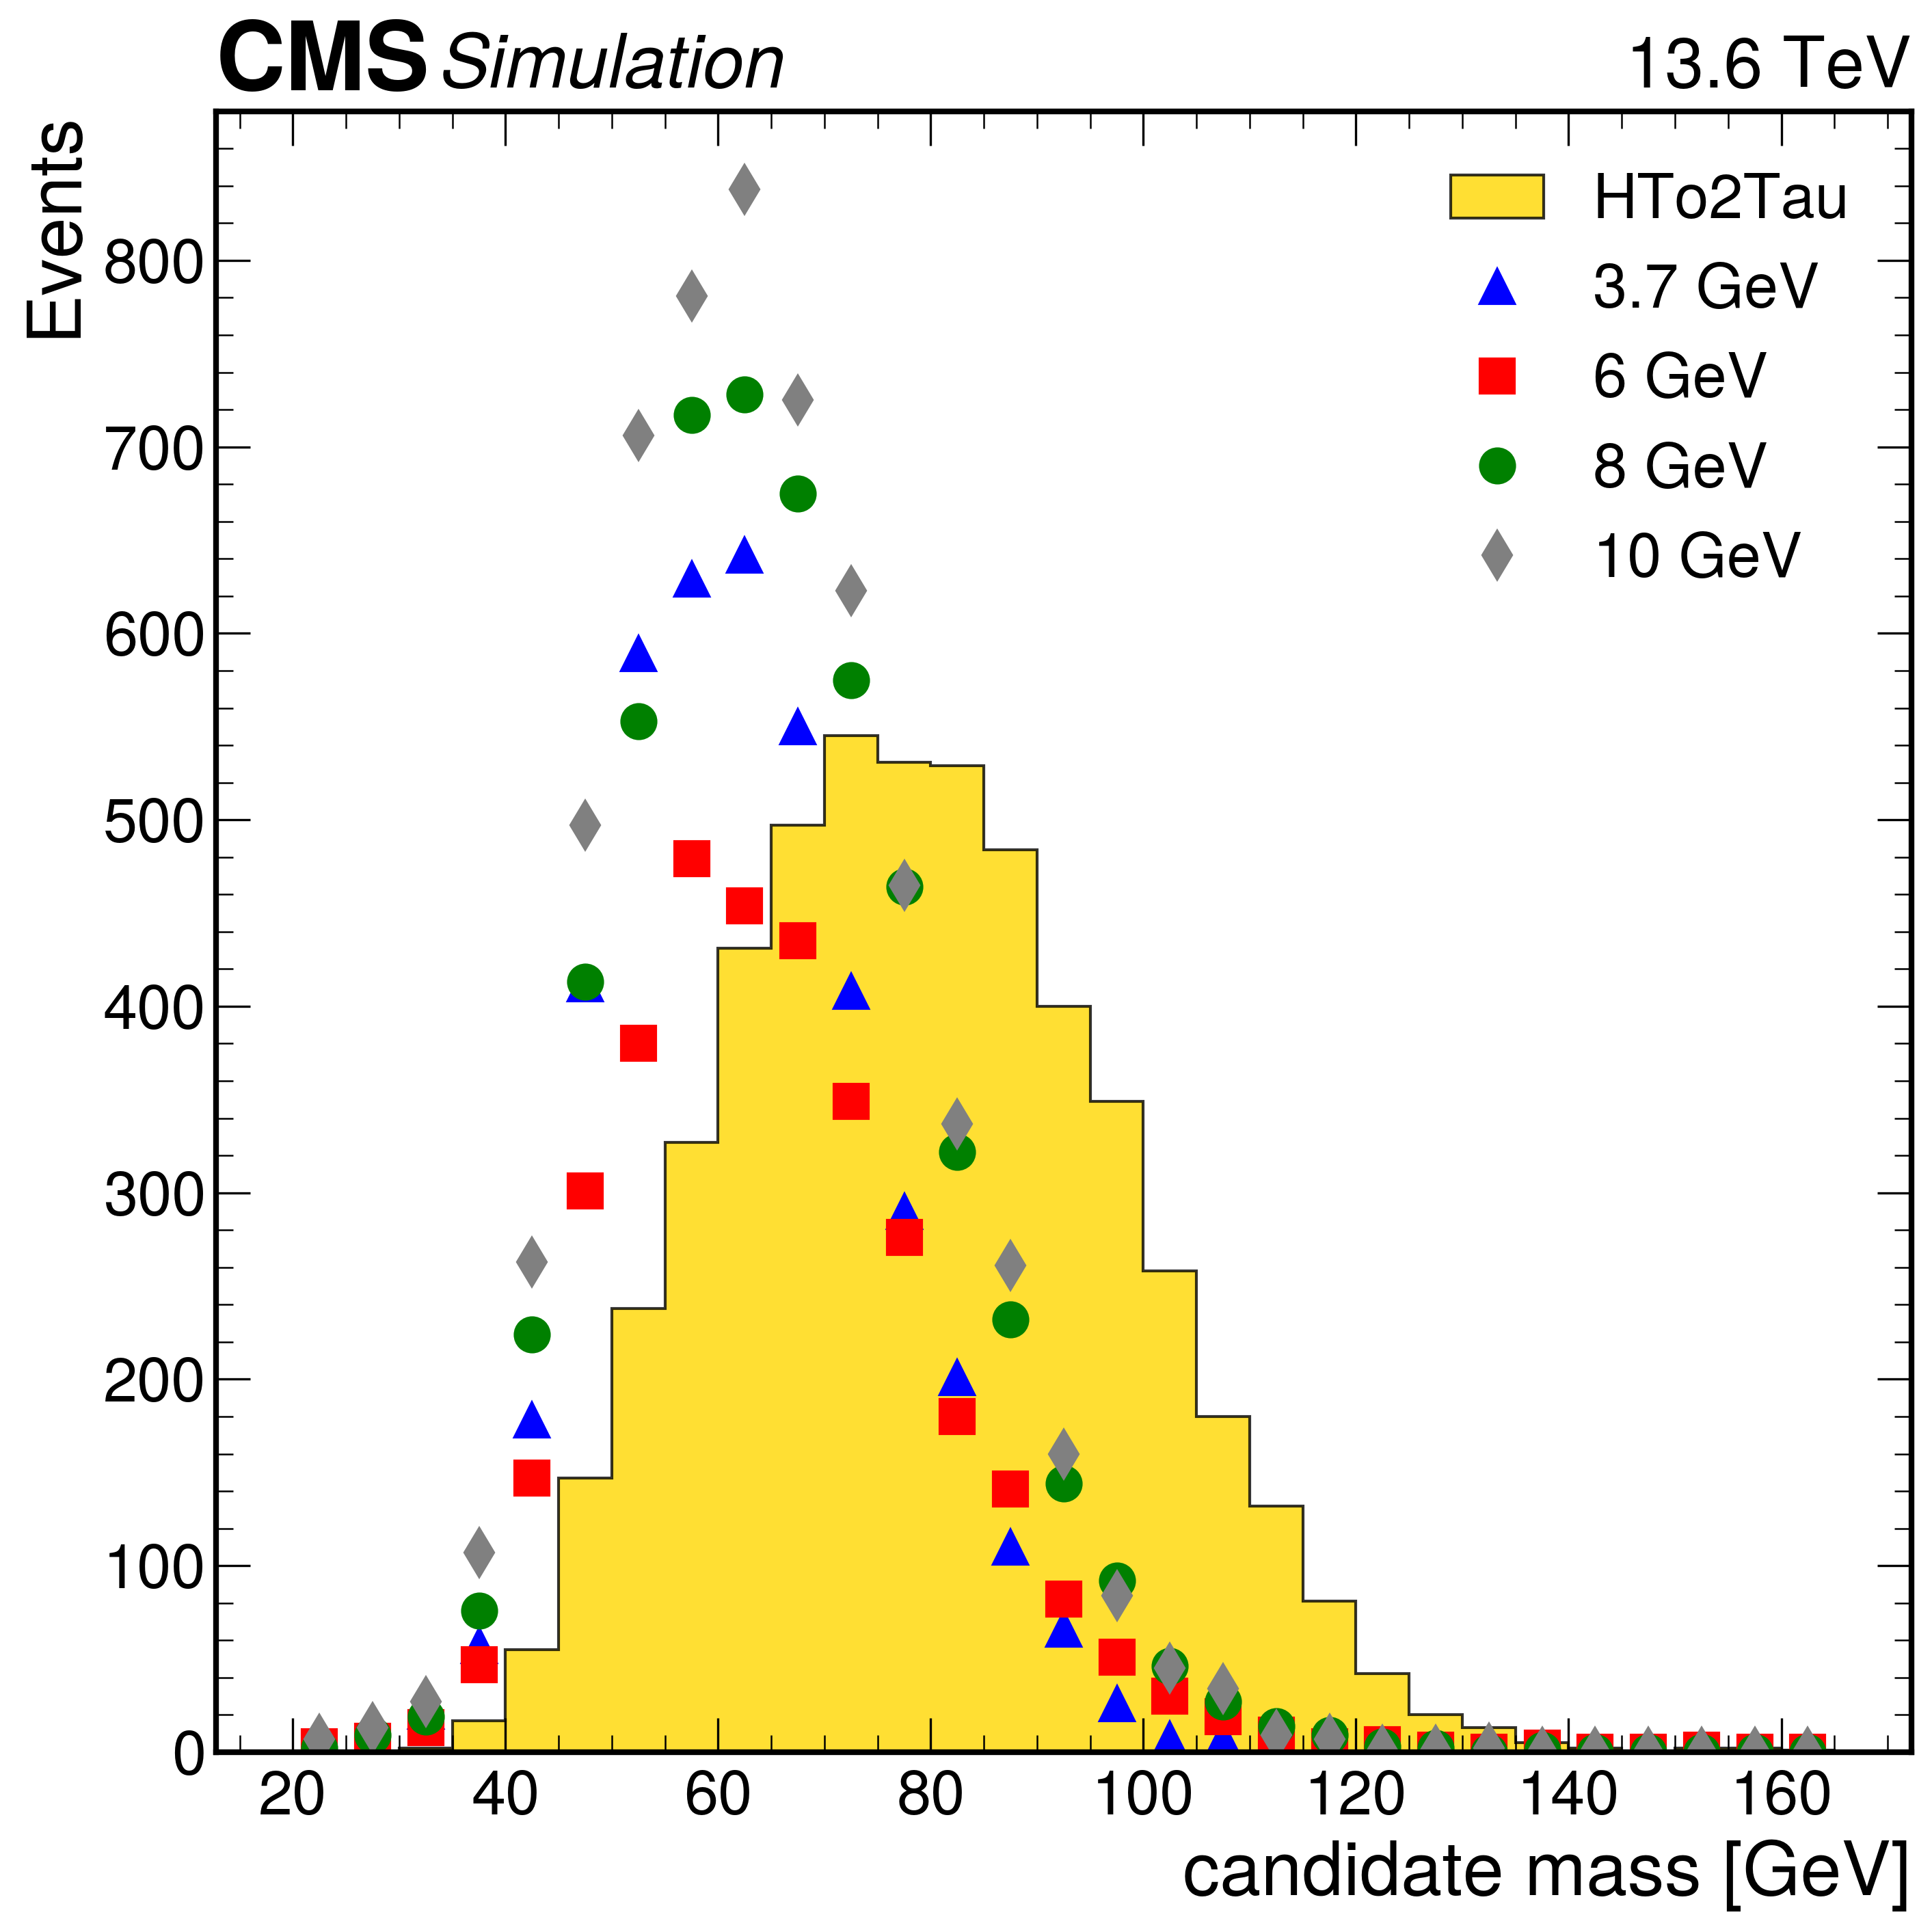

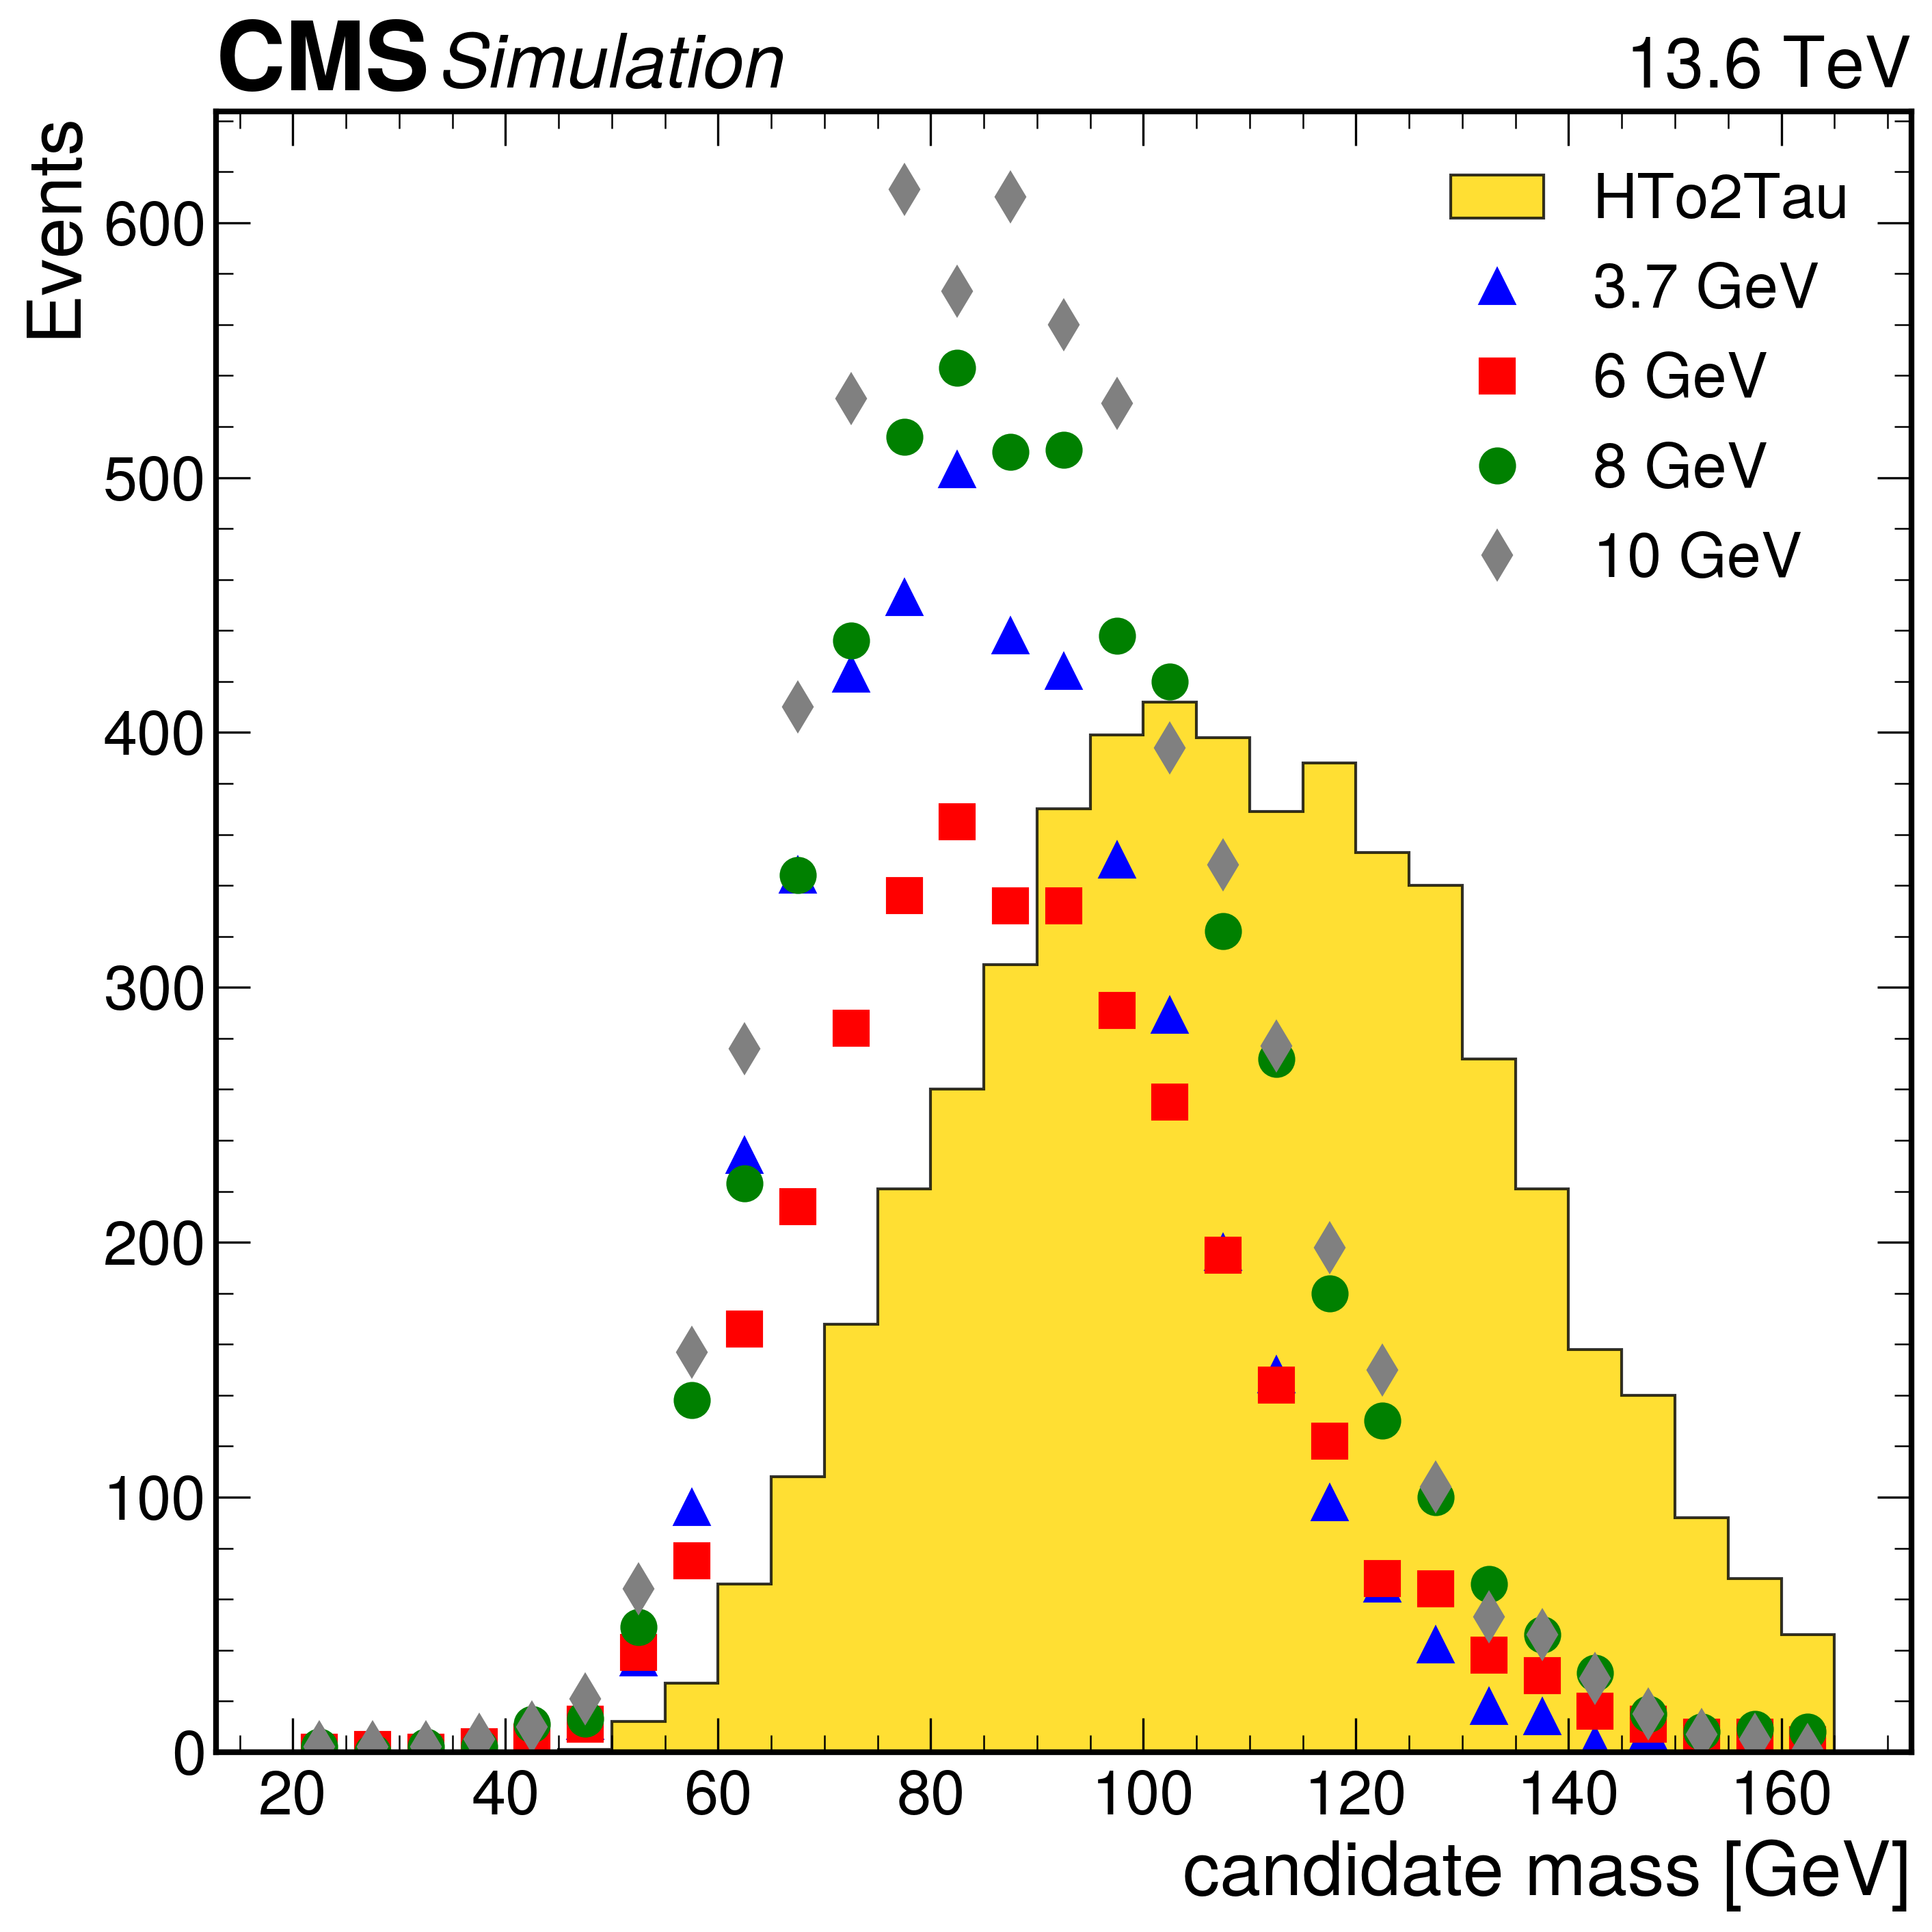

In [2]:
out_dir = '../analysis_run3/TauSVfit/output_pkl'

with open(f'{out_dir}/HTo2Tau_hadronic_pyroot.pkl', 'rb') as f:
    hto2tau = pickle.load(f)
    
with open(f'{out_dir}/NanoAOD_HToAATo4Tau_M3p7_pyroot.pkl', 'rb') as f:
    m3p7 = pickle.load(f)
    
with open(f'{out_dir}/NanoAOD_HToAATo4Tau_M6_pyroot.pkl', 'rb') as f:
    m6 = pickle.load(f)

with open(f'{out_dir}/NanoAOD_HToAATo4Tau_M8_pyroot.pkl', 'rb') as f:
    m8 = pickle.load(f)
    
with open(f'{out_dir}/NanoAOD_HToAATo4Tau_M10_pyroot.pkl', 'rb') as f:
    m10 = pickle.load(f)

# Get histograms from accumulator
h_mass_2taus_hto2tau_FastMTT = hto2tau['h_FastMTT_mass_exactly2']
h_mass_exactly2_hto2tau = hto2tau['h_mass_exactly2']

h_mass_2taus_m3p7_FastMTT = m3p7['h_FastMTT_mass_exactly2']
h_mass_exactly2_m3p7 = m3p7['h_mass_exactly2']

h_mass_2taus_m6_FastMTT = m6['h_FastMTT_mass_exactly2']
h_mass_exactly2_m6 = m6['h_mass_exactly2']

h_mass_2taus_m8_FastMTT = m8['h_FastMTT_mass_exactly2']
h_mass_exactly2_m8 = m8['h_mass_exactly2']

h_mass_2taus_m10_FastMTT = m10['h_FastMTT_mass_exactly2']
h_mass_exactly2_m10 = m10['h_mass_exactly2']

# Extract bin edges and counts
bins_hto2tau_FastMTT = h_mass_2taus_hto2tau_FastMTT["bins"]
bin_centers_hto2tau_FastMTT = 0.5 * (bins_hto2tau_FastMTT[1:] + bins_hto2tau_FastMTT[:-1])
counts_2_hto2tau_FastMTT = h_mass_2taus_hto2tau_FastMTT["values"]
counts_exactly2_hto2tau = h_mass_exactly2_hto2tau["values"]

bins_m3p7_FastMTT = h_mass_2taus_m3p7_FastMTT["bins"]
bin_centers_m3p7_FastMTT = 0.5 * (bins_m3p7_FastMTT[1:] + bins_m3p7_FastMTT[:-1])
counts_2_m3p7_FastMTT = h_mass_2taus_m3p7_FastMTT["values"]
counts_exactly2_m3p7 = h_mass_exactly2_m3p7["values"]



bins_m6_FastMTT = h_mass_2taus_m6_FastMTT["bins"]
bin_centers_m6_FastMTT = 0.5 * (bins_m6_FastMTT[1:] + bins_m6_FastMTT[:-1])
counts_2_m6_FastMTT = h_mass_2taus_m6_FastMTT["values"]
counts_exactly2_m6 = h_mass_exactly2_m6["values"]
# errors_2_m6 = np.sqrt(counts_2_m6)
# errors_more2_m6 = np.sqrt(counts_more2_m6)

bins_m8_FastMTT = h_mass_2taus_m8_FastMTT["bins"]
bin_centers_m8_FastMTT = 0.5 * (bins_m8_FastMTT[1:] + bins_m8_FastMTT[:-1])
counts_2_m8_FastMTT = h_mass_2taus_m8_FastMTT["values"]
counts_exactly2_m8 = h_mass_exactly2_m8["values"]
# errors_2_m8 = np.sqrt(counts_2_m8)
# errors_more2_m8 = np.sqrt(counts_more2_m8)

bins_m10_FastMTT = h_mass_2taus_m10_FastMTT["bins"]
bin_centers_m10_FastMTT = 0.5 * (bins_m10_FastMTT[1:] + bins_m10_FastMTT[:-1])
counts_2_m10_FastMTT = h_mass_2taus_m10_FastMTT["values"]
counts_exactly2_m10 = h_mass_exactly2_m10["values"]
# errors_2_m10 = np.sqrt(counts_2_m10)
# errors_more2_m10 = np.sqrt(counts_more2_m10)


# -------------------------
# Plot
# -------------------------

fig, ax = plt.subplots(dpi=300)

# Filled histogram (like yellow Higgs shape)
plt.hist(
    bins_hto2tau_FastMTT[:-1],
    bins=bins_hto2tau_FastMTT,
    weights=counts_exactly2_hto2tau,
    histtype="stepfilled",
    color="gold",
    edgecolor="black",
    alpha=0.8,
    label="HTo2Tau"
)

# Overlay second hist as points with errors
plt.errorbar(
    bin_centers_m3p7_FastMTT,
    counts_exactly2_m3p7,
    # yerr=errors_2_m3p7,
    fmt='^',
    markersize=12,
    color='blue',
    label="3.7 GeV",
    capsize=2
)
plt.errorbar(
    bin_centers_m6_FastMTT,
    counts_exactly2_m6,
    # yerr=errors_2_m6,
    fmt='s',
    markersize=12,
    color='red',
    label="6 GeV",
    capsize=2
)

plt.errorbar(
    bin_centers_m8_FastMTT,
    counts_exactly2_m8,
    # yerr=errors_2_m8,
    fmt='o',
    markersize=12,
    color='green',
    label="8 GeV",
    capsize=2
)

plt.errorbar(
    bin_centers_m10_FastMTT,
    counts_exactly2_m10,
    # yerr=errors_2_m10,
    fmt='d',
    markersize=12,
    color='grey',
    label="10 GeV",
    capsize=5
)

# Labels & styling
plt.xlabel("candidate mass [GeV]")
plt.ylabel("Events")
# plt.title("candidate_mass")
plt.legend()
hep.cms.label(llabel="Simulation", rlabel="13.6 TeV", loc=0, ax=ax)
plt.tight_layout()
# plt.savefig(f'plots/candidate_invarient_mass_from_excatelty_2_reco_tau_pyroot.pdf',facecolor='w',dpi=300)




fig, ax = plt.subplots(dpi=300)

# Filled histogram (like yellow Higgs shape)
plt.hist(
    bins_hto2tau_FastMTT[:-1],
    bins=bins_hto2tau_FastMTT,
    weights=counts_2_hto2tau_FastMTT,
    histtype="stepfilled",
    color="gold",
    edgecolor="black",
    alpha=0.8,
    label="HTo2Tau"
)

# Overlay second hist as points with errors
plt.errorbar(
    bin_centers_m3p7_FastMTT,
    counts_2_m3p7_FastMTT,
    # yerr=errors_2_m3p7,
    fmt='^',
    markersize=12,
    color='blue',
    label="3.7 GeV",
    capsize=2
)
plt.errorbar(
    bin_centers_m6_FastMTT,
    counts_2_m6_FastMTT,
    # yerr=errors_2_m6,
    fmt='s',
    markersize=12,
    color='red',
    label="6 GeV",
    capsize=2
)

plt.errorbar(
    bin_centers_m8_FastMTT,
    counts_2_m8_FastMTT,
    # yerr=errors_2_m8,
    fmt='o',
    markersize=12,
    color='green',
    label="8 GeV",
    capsize=2
)

plt.errorbar(
    bin_centers_m10_FastMTT,
    counts_2_m10_FastMTT,
    # yerr=errors_2_m10,
    fmt='d',
    markersize=12,
    color='grey',
    label="10 GeV",
    capsize=5
)

# Labels & styling
plt.xlabel("candidate mass [GeV]")
plt.ylabel("Events")
# plt.title("candidate_mass")
plt.legend()
hep.cms.label(llabel="Simulation", rlabel="13.6 TeV", loc=0, ax=ax)
plt.tight_layout()
# plt.savefig(f'plots/candidate_invarient_FastMTT_mass_from_excatelty_2_reco_tau_pyroot.pdf',facecolor='w',dpi=300)



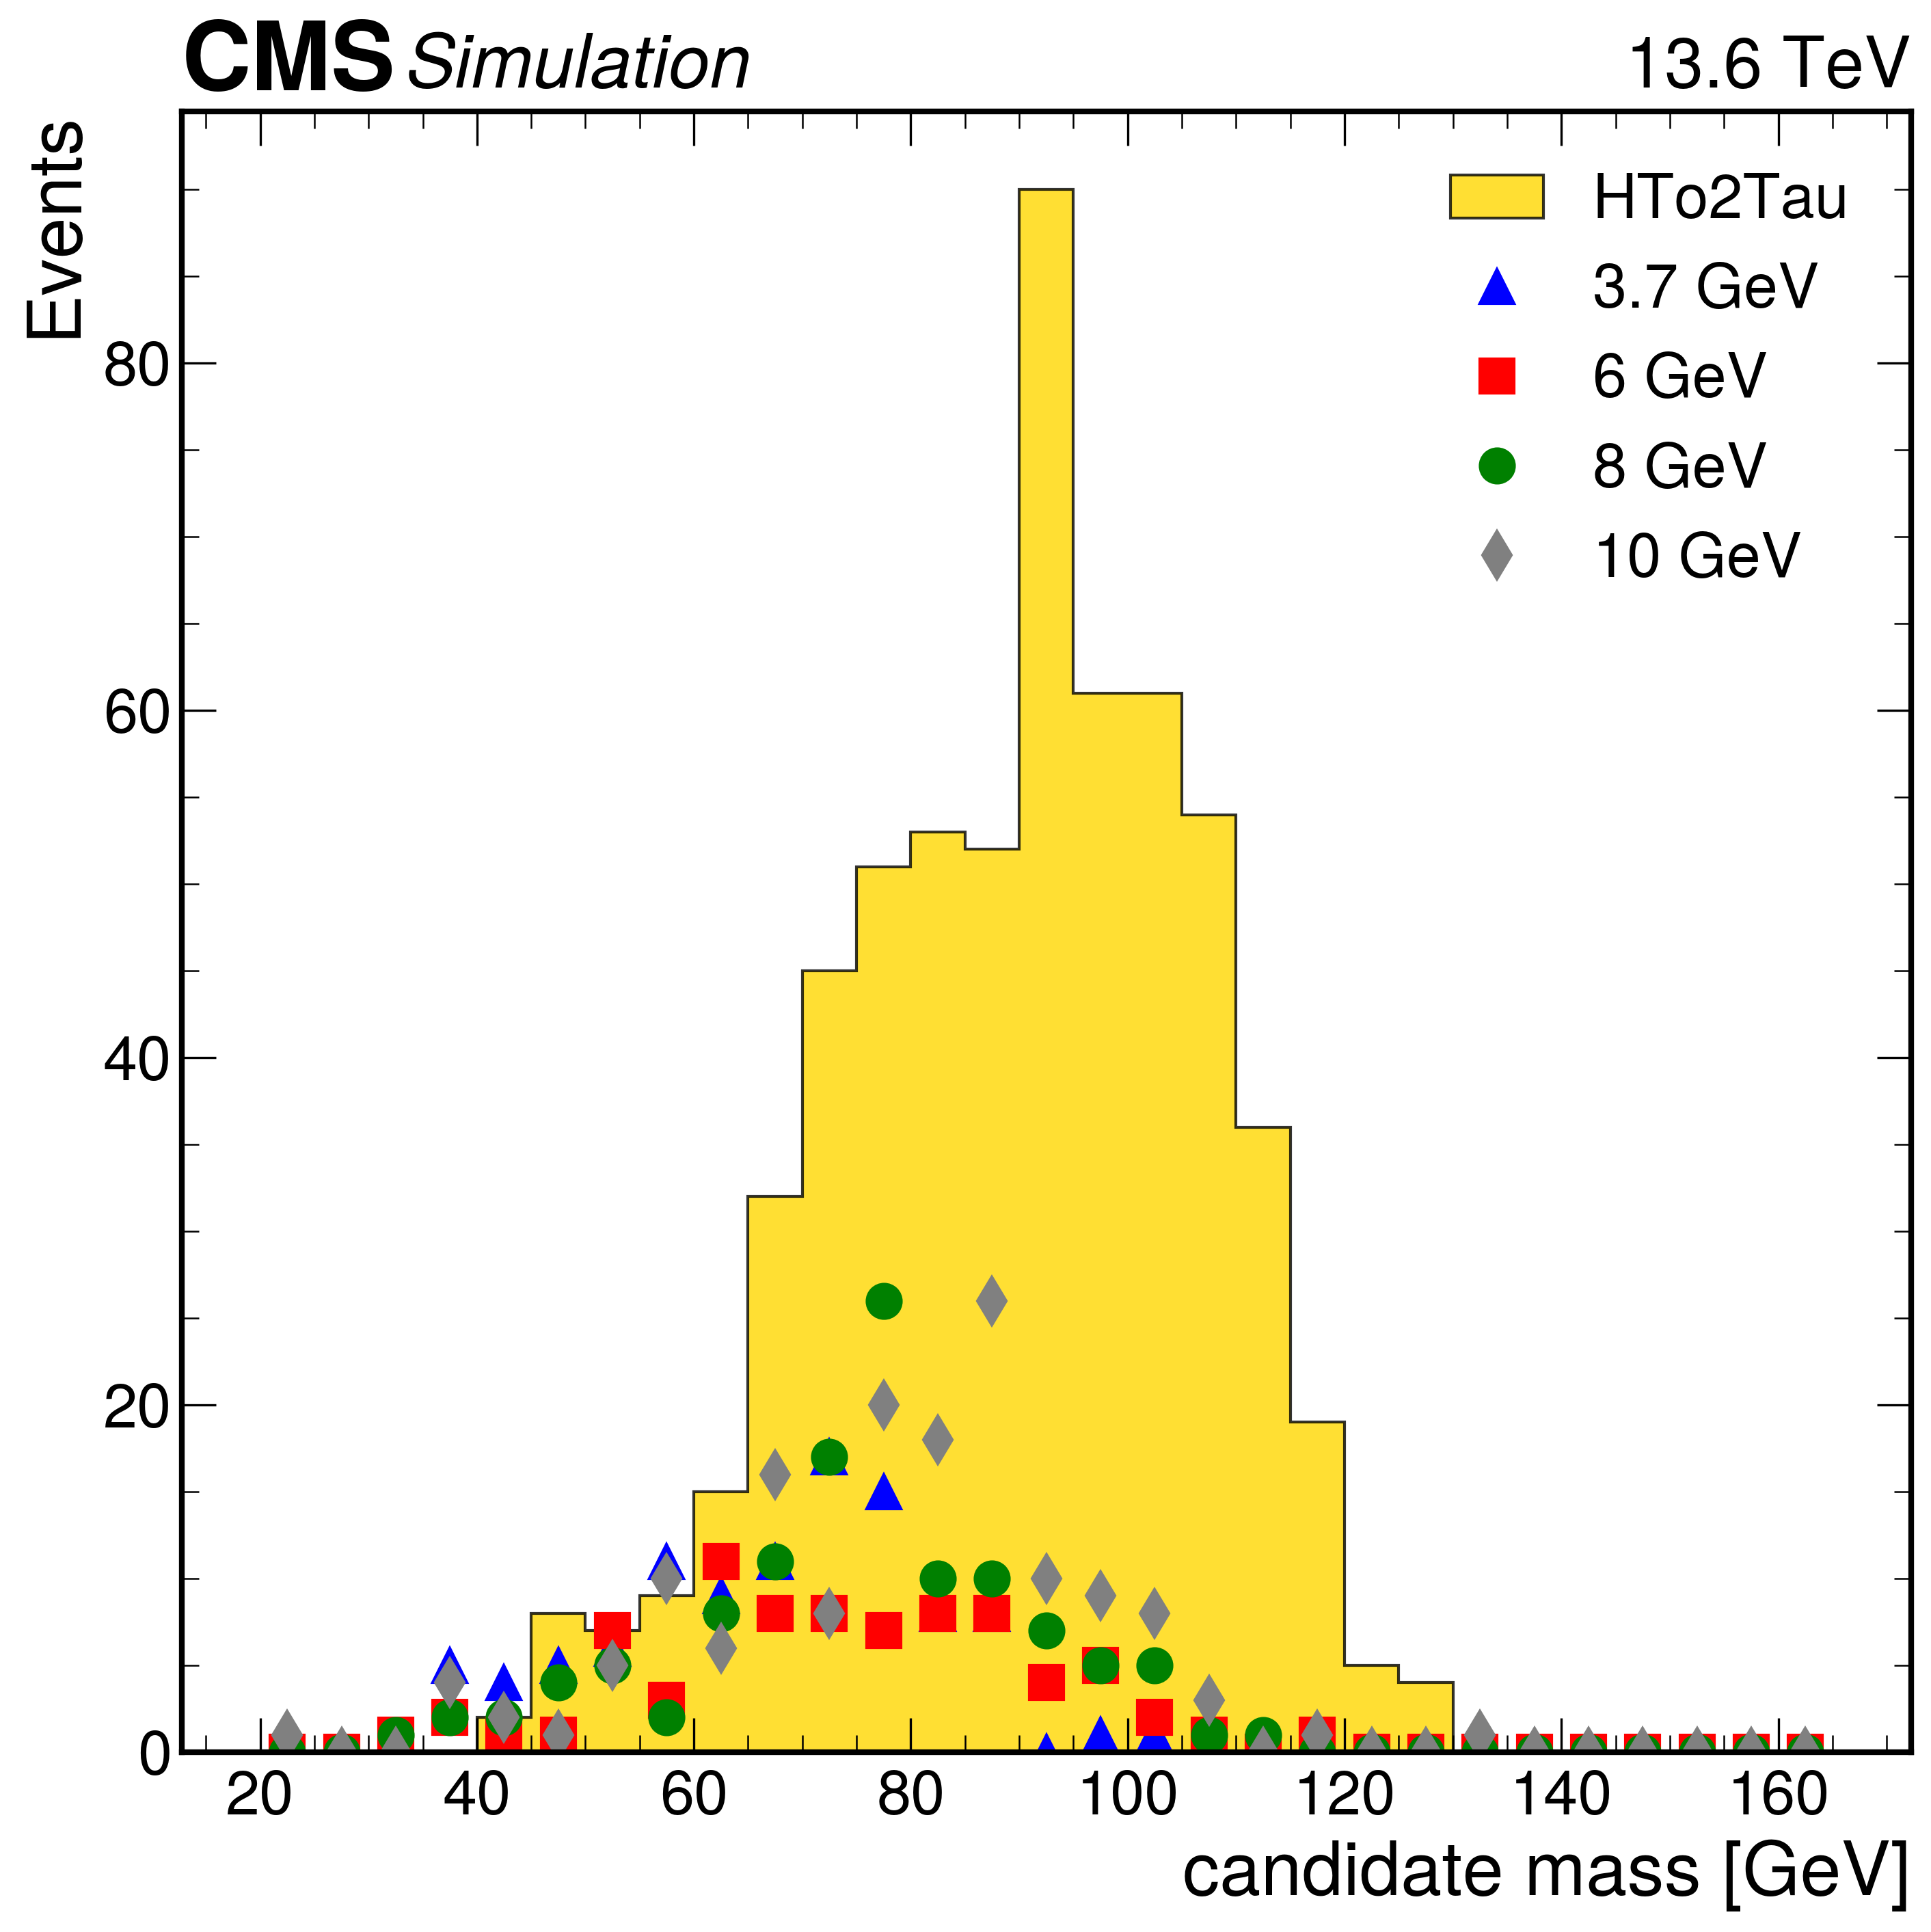

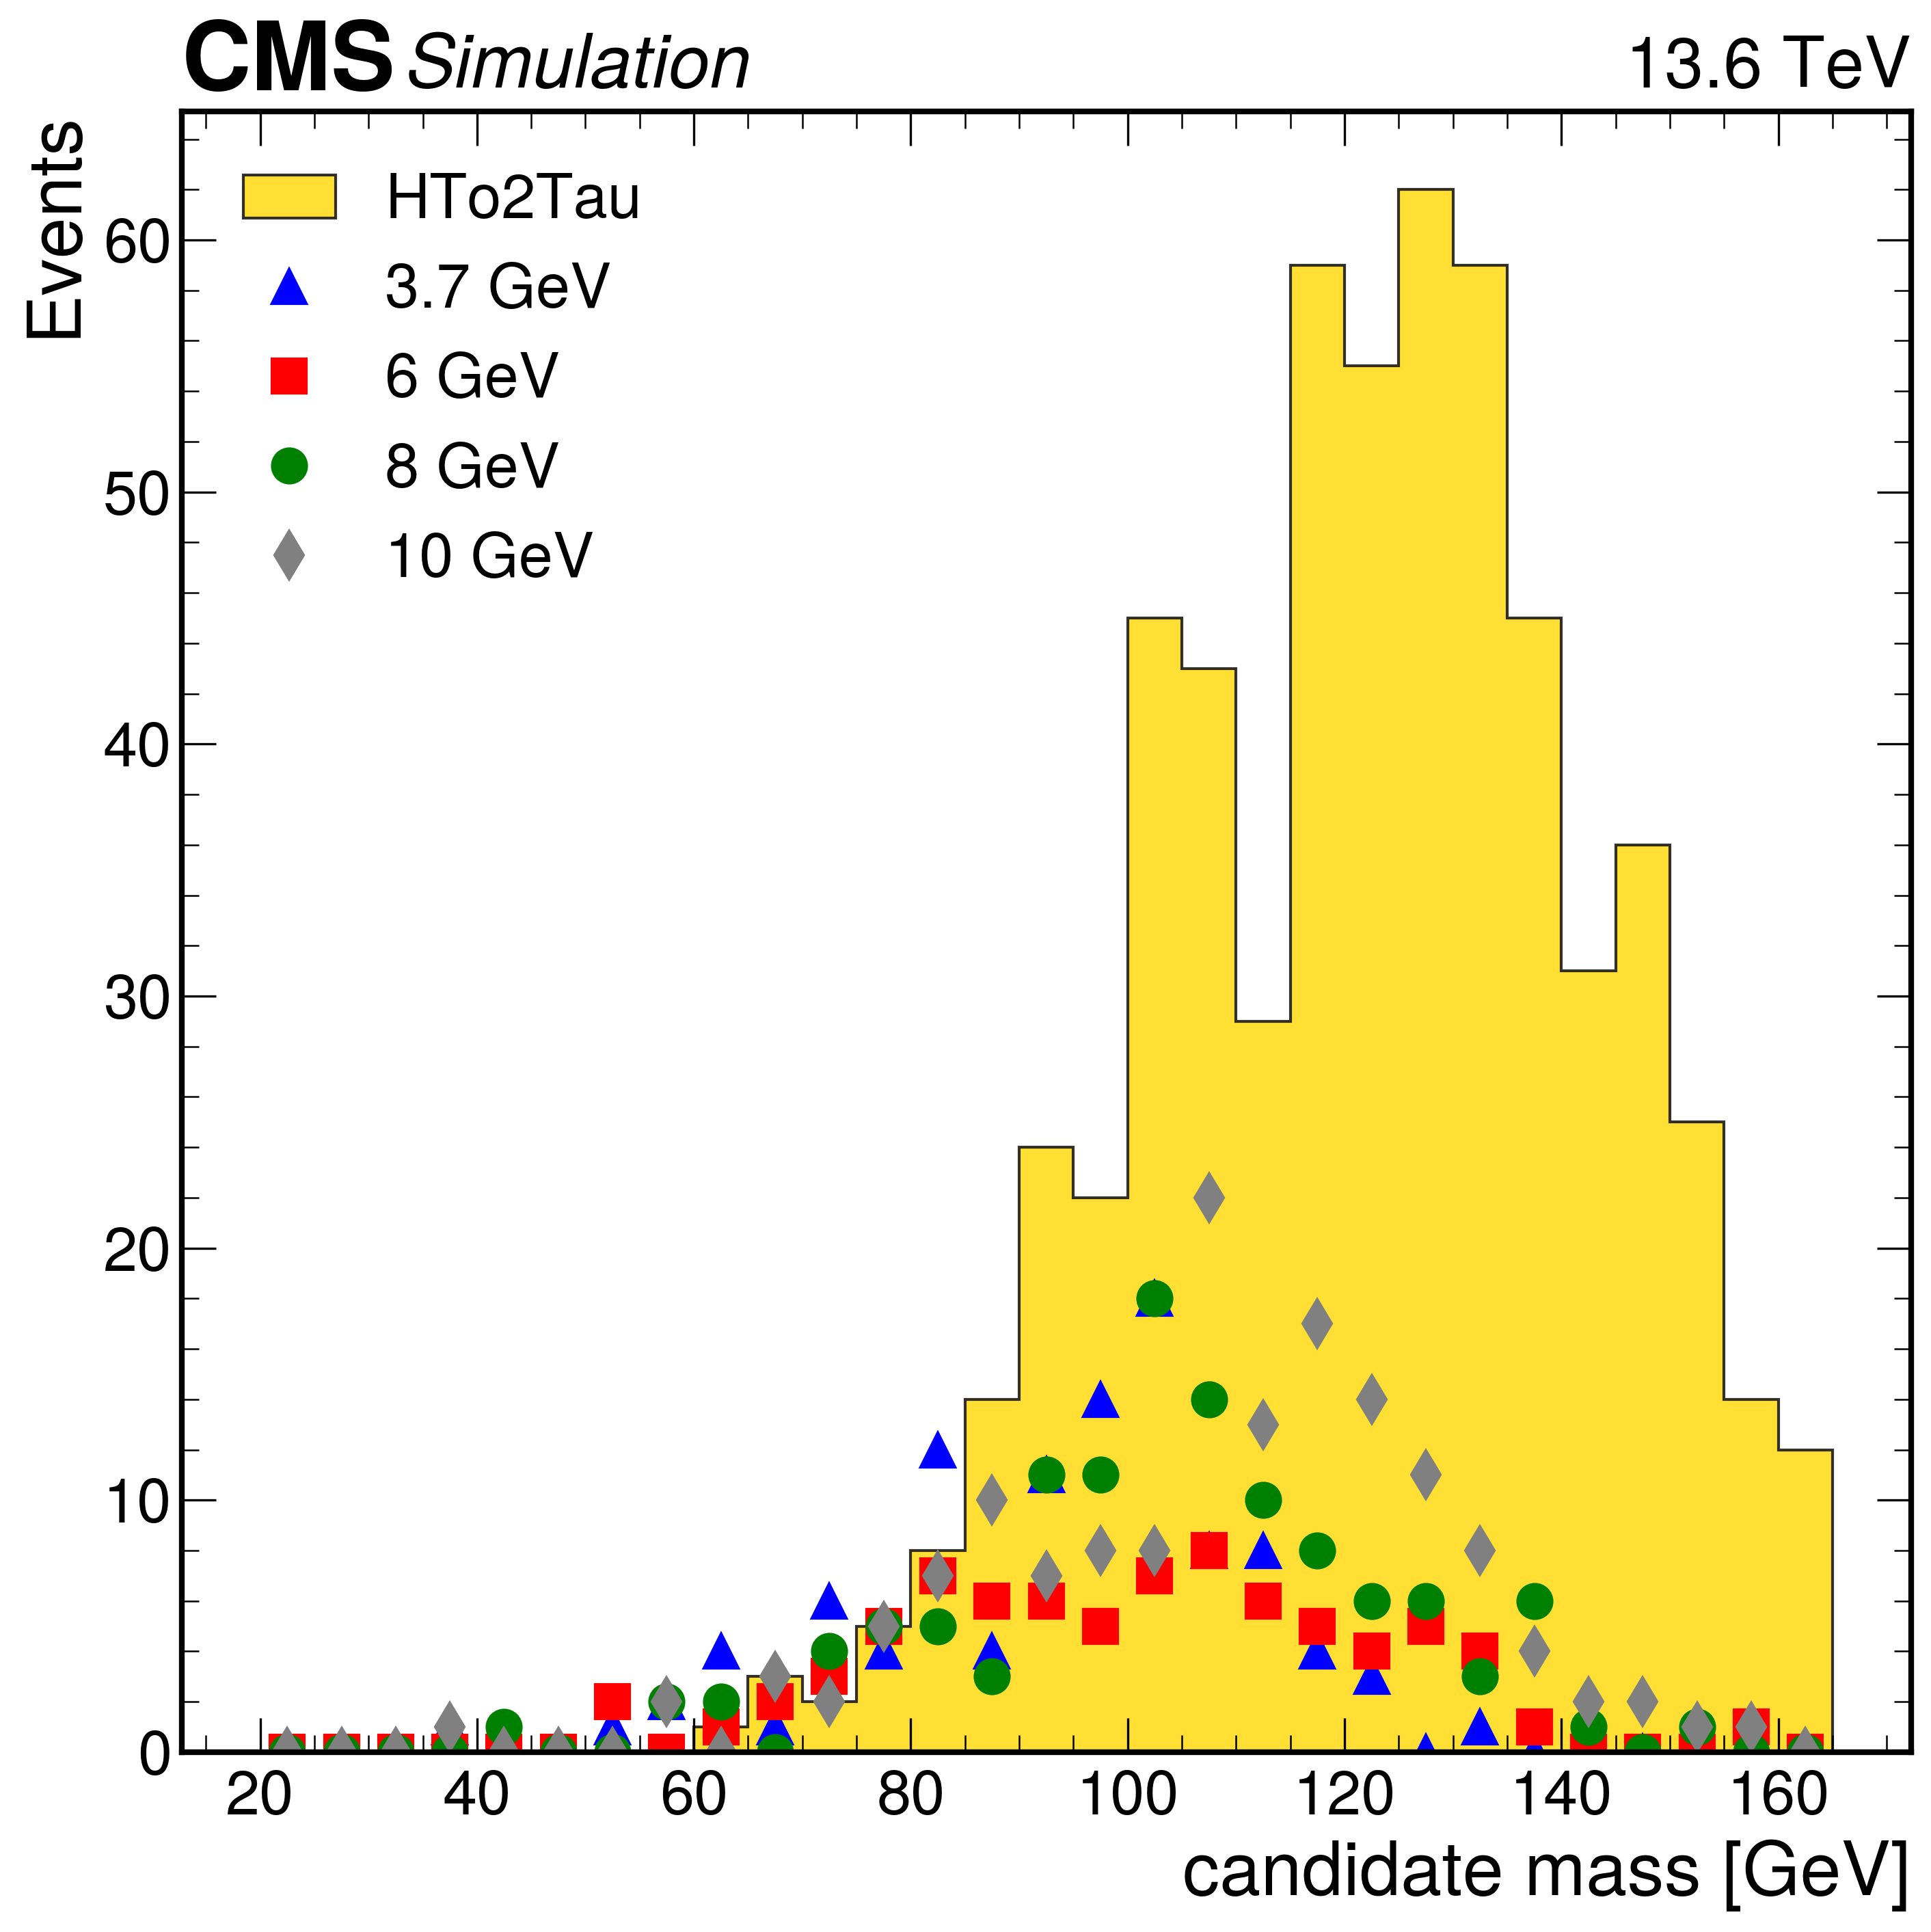

In [4]:
out_dir = '../analysis_run3/TauSVfit/output_pkl'

with open(f'{out_dir}/HTo2Tau_hadronic_trig_pyroot.pkl', 'rb') as f:
    hto2tau = pickle.load(f)
    
with open(f'{out_dir}/NanoAOD_HToAATo4Tau_M3p7_trig_pyroot.pkl', 'rb') as f:
    m3p7 = pickle.load(f)
    
with open(f'{out_dir}/NanoAOD_HToAATo4Tau_M6_trig_pyroot.pkl', 'rb') as f:
    m6 = pickle.load(f)

with open(f'{out_dir}/NanoAOD_HToAATo4Tau_M8_trig_pyroot.pkl', 'rb') as f:
    m8 = pickle.load(f)
    
with open(f'{out_dir}/NanoAOD_HToAATo4Tau_M10_trig_pyroot.pkl', 'rb') as f:
    m10 = pickle.load(f)

# Get histograms from accumulator
h_mass_2taus_hto2tau_FastMTT = hto2tau['h_FastMTT_mass_exactly2']
h_mass_exactly2_hto2tau = hto2tau['h_mass_exactly2']

h_mass_2taus_m3p7_FastMTT = m3p7['h_FastMTT_mass_exactly2']
h_mass_exactly2_m3p7 = m3p7['h_mass_exactly2']

h_mass_2taus_m6_FastMTT = m6['h_FastMTT_mass_exactly2']
h_mass_exactly2_m6 = m6['h_mass_exactly2']

h_mass_2taus_m8_FastMTT = m8['h_FastMTT_mass_exactly2']
h_mass_exactly2_m8 = m8['h_mass_exactly2']

h_mass_2taus_m10_FastMTT = m10['h_FastMTT_mass_exactly2']
h_mass_exactly2_m10 = m10['h_mass_exactly2']

# Extract bin edges and counts
bins_hto2tau_FastMTT = h_mass_2taus_hto2tau_FastMTT["bins"]
bin_centers_hto2tau_FastMTT = 0.5 * (bins_hto2tau_FastMTT[1:] + bins_hto2tau_FastMTT[:-1])
counts_2_hto2tau_FastMTT = h_mass_2taus_hto2tau_FastMTT["values"]
counts_exactly2_hto2tau = h_mass_exactly2_hto2tau["values"]

bins_m3p7_FastMTT = h_mass_2taus_m3p7_FastMTT["bins"]
bin_centers_m3p7_FastMTT = 0.5 * (bins_m3p7_FastMTT[1:] + bins_m3p7_FastMTT[:-1])
counts_2_m3p7_FastMTT = h_mass_2taus_m3p7_FastMTT["values"]
counts_exactly2_m3p7 = h_mass_exactly2_m3p7["values"]



bins_m6_FastMTT = h_mass_2taus_m6_FastMTT["bins"]
bin_centers_m6_FastMTT = 0.5 * (bins_m6_FastMTT[1:] + bins_m6_FastMTT[:-1])
counts_2_m6_FastMTT = h_mass_2taus_m6_FastMTT["values"]
counts_exactly2_m6 = h_mass_exactly2_m6["values"]
# errors_2_m6 = np.sqrt(counts_2_m6)
# errors_more2_m6 = np.sqrt(counts_more2_m6)

bins_m8_FastMTT = h_mass_2taus_m8_FastMTT["bins"]
bin_centers_m8_FastMTT = 0.5 * (bins_m8_FastMTT[1:] + bins_m8_FastMTT[:-1])
counts_2_m8_FastMTT = h_mass_2taus_m8_FastMTT["values"]
counts_exactly2_m8 = h_mass_exactly2_m8["values"]
# errors_2_m8 = np.sqrt(counts_2_m8)
# errors_more2_m8 = np.sqrt(counts_more2_m8)

bins_m10_FastMTT = h_mass_2taus_m10_FastMTT["bins"]
bin_centers_m10_FastMTT = 0.5 * (bins_m10_FastMTT[1:] + bins_m10_FastMTT[:-1])
counts_2_m10_FastMTT = h_mass_2taus_m10_FastMTT["values"]
counts_exactly2_m10 = h_mass_exactly2_m10["values"]
# errors_2_m10 = np.sqrt(counts_2_m10)
# errors_more2_m10 = np.sqrt(counts_more2_m10)


# -------------------------
# Plot
# -------------------------

fig, ax = plt.subplots(dpi=300)

# Filled histogram (like yellow Higgs shape)
plt.hist(
    bins_hto2tau_FastMTT[:-1],
    bins=bins_hto2tau_FastMTT,
    weights=counts_exactly2_hto2tau,
    histtype="stepfilled",
    color="gold",
    edgecolor="black",
    alpha=0.8,
    label="HTo2Tau"
)

# Overlay second hist as points with errors
plt.errorbar(
    bin_centers_m3p7_FastMTT,
    counts_exactly2_m3p7,
    # yerr=errors_2_m3p7,
    fmt='^',
    markersize=12,
    color='blue',
    label="3.7 GeV",
    capsize=2
)
plt.errorbar(
    bin_centers_m6_FastMTT,
    counts_exactly2_m6,
    # yerr=errors_2_m6,
    fmt='s',
    markersize=12,
    color='red',
    label="6 GeV",
    capsize=2
)

plt.errorbar(
    bin_centers_m8_FastMTT,
    counts_exactly2_m8,
    # yerr=errors_2_m8,
    fmt='o',
    markersize=12,
    color='green',
    label="8 GeV",
    capsize=2
)

plt.errorbar(
    bin_centers_m10_FastMTT,
    counts_exactly2_m10,
    # yerr=errors_2_m10,
    fmt='d',
    markersize=12,
    color='grey',
    label="10 GeV",
    capsize=5
)

# Labels & styling
plt.xlabel("candidate mass [GeV]")
plt.ylabel("Events")
# plt.title("candidate_mass")
plt.legend()
hep.cms.label(llabel="Simulation", rlabel="13.6 TeV", loc=0, ax=ax)
plt.tight_layout()
# plt.savefig(f'plots/candidate_invarient_mass_from_excatelty_2_reco_tau_with_trig_pyroot.pdf',facecolor='w',dpi=300)




fig, ax = plt.subplots(dpi=300)

# Filled histogram (like yellow Higgs shape)
plt.hist(
    bins_hto2tau_FastMTT[:-1],
    bins=bins_hto2tau_FastMTT,
    weights=counts_2_hto2tau_FastMTT,
    histtype="stepfilled",
    color="gold",
    edgecolor="black",
    alpha=0.8,
    label="HTo2Tau"
)

# Overlay second hist as points with errors
plt.errorbar(
    bin_centers_m3p7_FastMTT,
    counts_2_m3p7_FastMTT,
    # yerr=errors_2_m3p7,
    fmt='^',
    markersize=12,
    color='blue',
    label="3.7 GeV",
    capsize=2
)
plt.errorbar(
    bin_centers_m6_FastMTT,
    counts_2_m6_FastMTT,
    # yerr=errors_2_m6,
    fmt='s',
    markersize=12,
    color='red',
    label="6 GeV",
    capsize=2
)

plt.errorbar(
    bin_centers_m8_FastMTT,
    counts_2_m8_FastMTT,
    # yerr=errors_2_m8,
    fmt='o',
    markersize=12,
    color='green',
    label="8 GeV",
    capsize=2
)

plt.errorbar(
    bin_centers_m10_FastMTT,
    counts_2_m10_FastMTT,
    # yerr=errors_2_m10,
    fmt='d',
    markersize=12,
    color='grey',
    label="10 GeV",
    capsize=5
)

# Labels & styling
plt.xlabel("candidate mass [GeV]")
plt.ylabel("Events")
# plt.title("candidate_mass")
plt.legend()
hep.cms.label(llabel="Simulation", rlabel="13.6 TeV", loc=0, ax=ax)
plt.tight_layout()
# plt.savefig(f'plots/candidate_invarient_FastMTT_mass_from_excatelty_2_reco_tau_with_trig_pyroot.pdf',facecolor='w',dpi=300)



2921


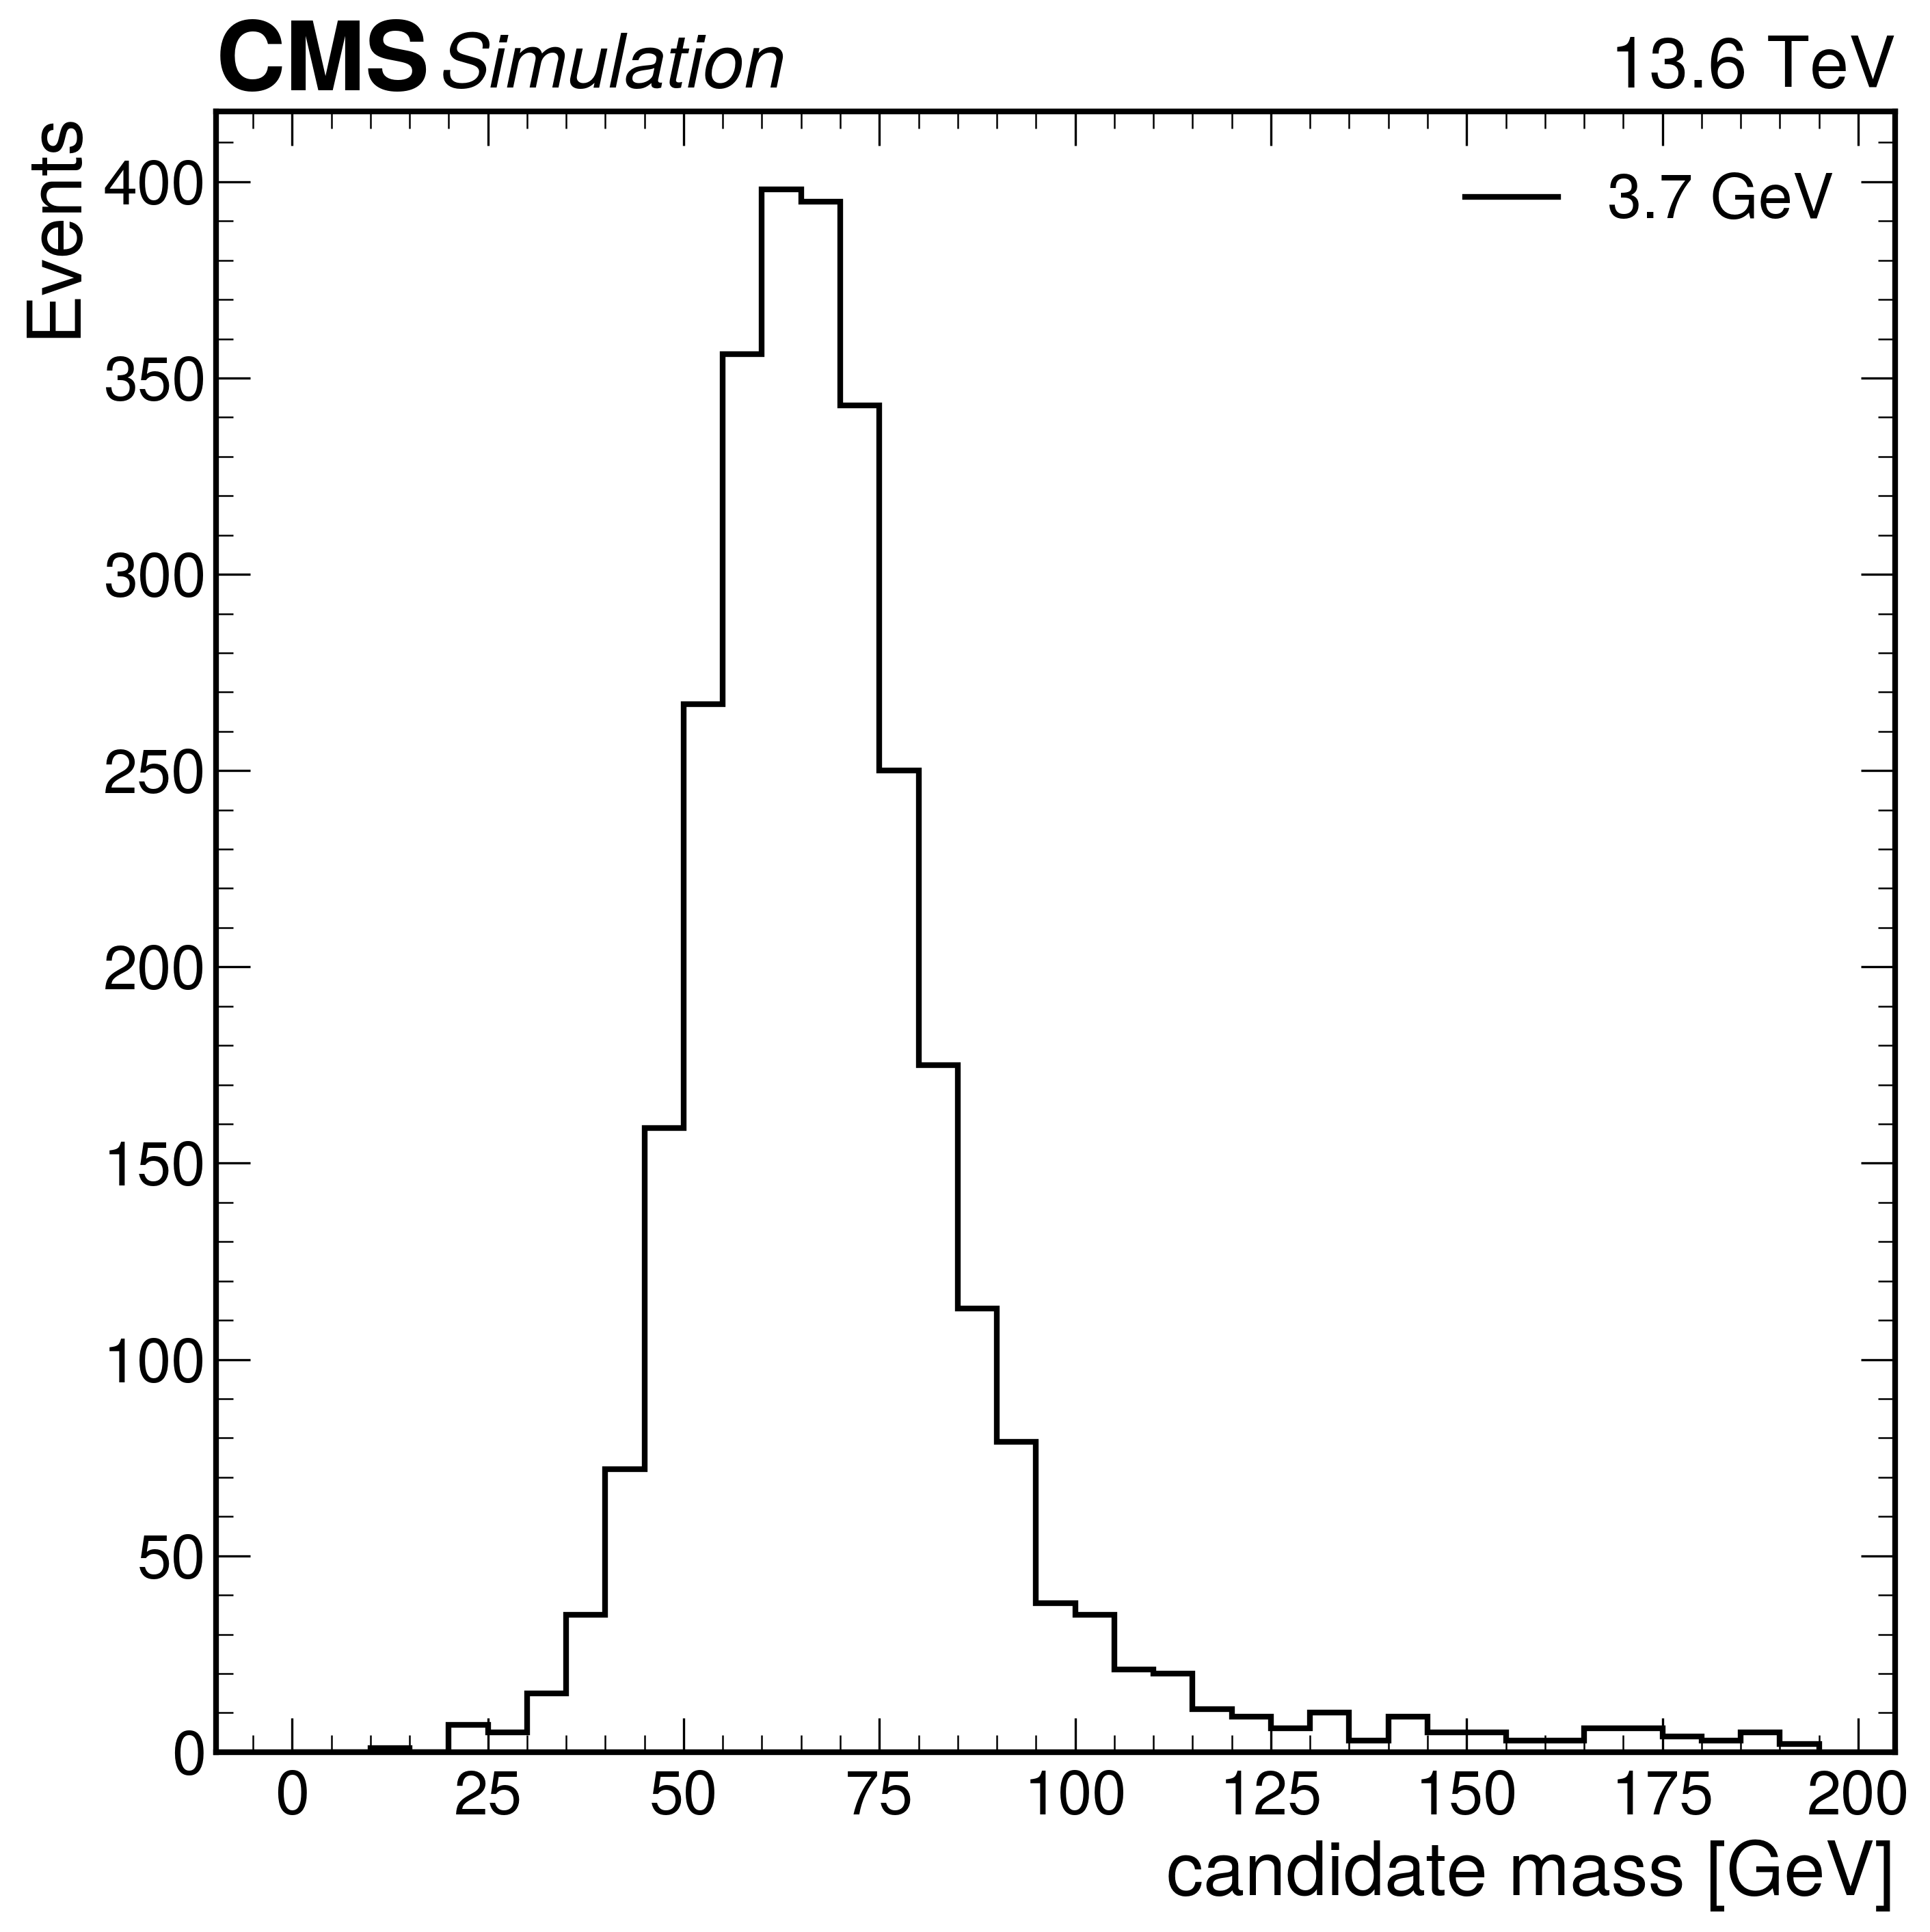

In [14]:
out_dir = '../analysis_run3/TauSVfit/output_pkl'
with open(f'{out_dir}/NanoAOD_HToAATo4Tau_M3p7_higgs_inv_mass_pyroot.pkl', 'rb') as f:
    hto2tau = pickle.load(f)
    


# Get histograms from accumulator
h_mass = hto2tau['h_inv_mass']
# h_mass_more2_hto2tau = hto2tau['h_mass_morethan1']
print(len(h_mass_2taus_hto2tau))

MASS_BINS = np.arange(0,200,5)


h1 = np.histogram(h_mass, bins=MASS_BINS,)
fig, ax = plt.subplots(dpi=300)
hep.histplot(h1, histtype='step',yerr=False, linestyle='-', linewidth=2, color='black', label=rf"3.7 GeV", density=0)

# Labels & styling
plt.xlabel("candidate mass [GeV]")
plt.ylabel("Events")
# plt.title("candidate_mass")
plt.legend()
hep.cms.label(llabel="Simulation", rlabel="13.6 TeV", loc=0, ax=ax)
plt.tight_layout()
# plt.savefig(f'plot/candidate_invarient_mass_from_2_or_more_reco_tau_pass_trig.pdf',facecolor='w',dpi=300)


In [15]:
file = uproot.open("../analysis_run3/analyzer_from_Ruchi/signal_back_processing/CMSSW_13_0_14/src/MLAnalyzerRun3/HToAToTauTau_TTbar.root")
root = file["fevt"]

In [16]:
root.keys()

['RHTree;10',
 'RHTree;9',
 'h_sel;1',
 'hNpassed_hlt;1',
 'hNpassed_kin;1',
 'hNpassed_MVA;1',
 'hNpassed_2Tau;1',
 'hNpassed_2TauDr;1',
 'hNpassed_mTT;1',
 'hNpassed_nRecoPho;1',
 'hNpassed_svfitmass;1',
 'HBHE_energy;1',
 'HBHE_energy_EB;1',
 'HBHE_energy_AOD;1',
 'HBHE_energy_EB_AOD;1',
 'HBHE_energy_miniAOD;1',
 'HBHE_energy_EB_miniAOD;1',
 'ECAL_energy;1',
 'ECAL_energy_AOD;1',
 'ECAL_energy_miniAOD;1',
 'ECAL_tracks_atECALfixIP;1',
 'ECAL_tracksPt_atECALfixIP;1',
 'ECAL_tracksQPt_atECALfixIP;1',
 'ECAL_tracksD0_atECALfixIP;1',
 'ECAL_tracksD0Sig_atECALfixIP;1',
 'ECAL_tracksDz_atECALfixIP;1',
 'ECAL_tracksDzSig_atECALfixIP;1',
 'TOB_layer1_ECAL_atPV;1',
 'TOB_layer2_ECAL_atPV;1',
 'TOB_layer3_ECAL_atPV;1',
 'TOB_layer4_ECAL_atPV;1',
 'TOB_layer5_ECAL_atPV;1',
 'TOB_layer6_ECAL_atPV;1',
 'TEC_layer1_ECAL_atPV;1',
 'TEC_layer2_ECAL_atPV;1',
 'TEC_layer3_ECAL_atPV;1',
 'TEC_layer4_ECAL_atPV;1',
 'TEC_layer5_ECAL_atPV;1',
 'TEC_layer6_ECAL_atPV;1',
 'TEC_layer7_ECAL_atPV;1',
 'TEC_l

In [27]:
h_sel = root["h_sel"]
values_h_sel, edges_h_sel = h_sel.to_numpy()
values_h_sel

array([2762.,  237.], dtype=float32)

np.float32(2762.0)

In [28]:
hNpassed_hlt = root["hNpassed_hlt"]
values_hNpassed_hlt, edges_hNpassed_hlt = hNpassed_hlt.to_numpy()
values_hNpassed_hlt

array([2712.,   62.,  202.,   49.,    0.,    0.,    0.,    0.,    0.,
          0.], dtype=float32)